# **Bank Marketing** | KNN 21032025
---
`Copyright @ SMK Negeri 8 Malang. All rights reserved.`
- Lovi Adiva Alexandria (Markdown, Modeling, Visualization)
- Maulana El Jauziyah Al-Ghani (EDA, Preprocessing, Evaluation)

# **I. Data Understanding**

## ***A. Penjabaran Studi Kasus***

Kami diberikan dataset oleh manager perusahaan bank yang berisikan data data nasabah mengenai interaksi nasabah kepada bank sebelum dan sesudah kampanye pemasaran yang dilakukan dan apakah nasabah tersebut akhirnya berlangganan dalam jangka panjang atau tidak. Manager menginginkan kita untuk membuat model menggunakan **KNN** untuk memprediksi apakah suatu calon nasabah akan melakukan langganan atau tidak dan mengetahui faktor apa saja yang mempengaruhi calon nasabah untuk berlangganan.

Manager mengambil dataset dalam waktu satu tahun mulai dari januari sampai desember dan diberikan kepada kami sebulan setelahnya, early january.

## ***B. Import Libraries***

In [836]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## ***C. Import Dataset***

In [837]:
dataset = pd.read_csv("bank.csv", delimiter=";")

In [838]:
dataset

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


# **II. Data Preparation**

## ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [839]:
dataset.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

Pengertian dari kolom-kolom tersebut:
1. `Age`: Usia nasabah
2. `job`: Pekerjaan Nasabah
3. `marital`: Status pernikahan nasabah
4. `education`: Tingkat pendidikan nasabah
5. `default`: Apakah nasabah memiliki kredit macet sebelumnya 
6. `balance`: Saldo rata rata nasabah
7. `housing`: Apakah nasabah memiliki pinjaman rumah
8. `loan`: Apakah nasabah memiliki hutang
9. `contact`: Jenis device yang digunakan nasabah untuk menghubungi bank
10. `day`: Berapa lama nasabah terakhir kali menghubungi bank dalam hitungan hari
11. `month`: Berapa lama nasabah terakhir kali menghubungi bank dalam hitungan bulan
12. `duration`: Berapa lama nasabah menghubungi bak
13. `campaign`: Berapa banyak nasabah melakukan contact ke bank dalam kampanye pemasaran yang sedang dilakukan
14. `pdays`: Berapa lama bank terakhir kali menghubungi nasabah dalam kampanye pemasaran sebelumnya, -1 berarti nasabah tidak pernah menghubungi bank
15. `previous`: Berapa banyak bank melakukan contact kepada nasabah sebelum kampanye pemasaran
16. `poutcome`: Hasil dari kampanye pemasaran sebelumnya
17. `y`: Apakah nasabah akan berlangganan dalam jangka waktu panjang atau tidak (kolom target)

Informasi - informasi yang terdapat di dataset merupakan hasil survey kepada calon nasabah, history interaksi calon nasabah dengan bank, dan status finansial calon nasabah 

### 2. Inspeksi Informasi Ringkas

In [840]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


### 3. Inspeksi Statistik Deskriptif

In [841]:
dataset.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [842]:
dataset[['balance', 'age', 'day', 'duration']].var()

balance     9.057922e+06
age         1.118562e+02
day         6.802402e+01
duration    6.752547e+04
dtype: float64

In [843]:
dataset[['balance', 'age', 'day', 'duration']].median()

balance     444.0
age          39.0
day          16.0
duration    185.0
dtype: float64

In [844]:
def data_range(dataset, columns_to_process):
    for col in columns_to_process:
        Q1 = dataset[col].quantile(0.25)
        Q3 = dataset[col].quantile(0.75)
        IQR = Q3 - Q1

        print(f"=== Kolom: {col} ===")
        print(f"Q1: {Q1}")
        print(f"Q3: {Q3}")
        print(f"IQR: {IQR}\n")

    return dataset  

outlier = data_range(dataset[['balance', 'age', 'day', 'duration',]], dataset[['balance', 'age', 'day', 'duration']].columns)

=== Kolom: balance ===
Q1: 69.0
Q3: 1480.0
IQR: 1411.0

=== Kolom: age ===
Q1: 33.0
Q3: 49.0
IQR: 16.0

=== Kolom: day ===
Q1: 9.0
Q3: 21.0
IQR: 12.0

=== Kolom: duration ===
Q1: 104.0
Q3: 329.0
IQR: 225.0



### 4. Inspeksi Data NaN

In [845]:
dataset.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

### 5. Inspeksi Data Duplicated

In [846]:
dataset.duplicated().sum()

np.int64(0)

### 6. Univariate Analysis

#### *a. Inspeksi Distribusi Kelas Target*

In [847]:
target_count = dataset['y'].value_counts()
target_count

y
no     4000
yes     521
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x1890bc79a60>,
 [Text(0.5620337769621356, -1.0033035600224274, 'no'),
  Text(-0.562035060704308, 1.0033028408905782, 'yes')],
 [Text(0.3176712652394679, -0.5670846208822415, '88.5%'),
  Text(-0.3176719908328697, 0.5670842144164137, '11.5%')])

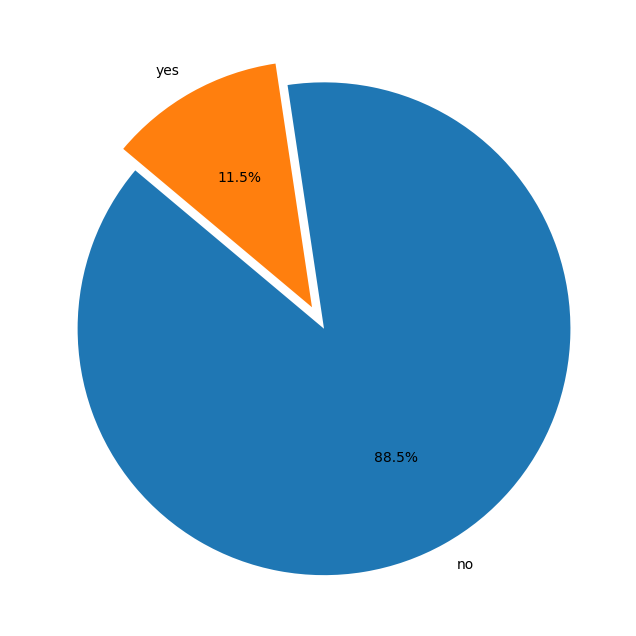

In [848]:
explodes = [0.05] * len(target_count)
color = plt.get_cmap('tab10').colors

plt.figure(figsize=(8, 8))
plt.pie(
    target_count,
    labels =target_count.index,
    explode=explodes,
    colors=color,
    autopct="%1.1f%%",
    startangle=140
)

Kebanyakan calon nasabah dari hasil survey di atas memilih untuk tidak menjadi nasabah di bank tersebut. Maka, diperlukan proses oversampling sebelum data diproses ke model.

#### *b. Inspeksi Distribusi Kelas Fitur*

In [849]:
categorical_feature = []

def value_check(dataset, feature):
    for col in dataset[feature]:
        print("=" * 40)
        print(f'Value Counts for: {col}')
        print("=" * 40)
        print(dataset[col].value_counts(dropna=False))
        print("\n")

value_check(dataset, categorical_feature)

Value Counts for: job
job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64


Value Counts for: marital
marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64


Value Counts for: education
education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64


Value Counts for: default
default
no     4445
yes      76
Name: count, dtype: int64


Value Counts for: housing
housing
yes    2559
no     1962
Name: count, dtype: int64


Value Counts for: loan
loan
no     3830
yes     691
Name: count, dtype: int64


Value Counts for: contact
contact
cellular     2896
unknown      1324
telephone     301
Name: count, dtype: int64


Value Counts for: month
month
may    1398
jul     706
aug     633
jun     5

### 7. Bivariate Analysis

#### *a. Inspeksi Distribusi Fitur berdasarkan Target*

- Inspeksi menggunakan visualisasi histplot

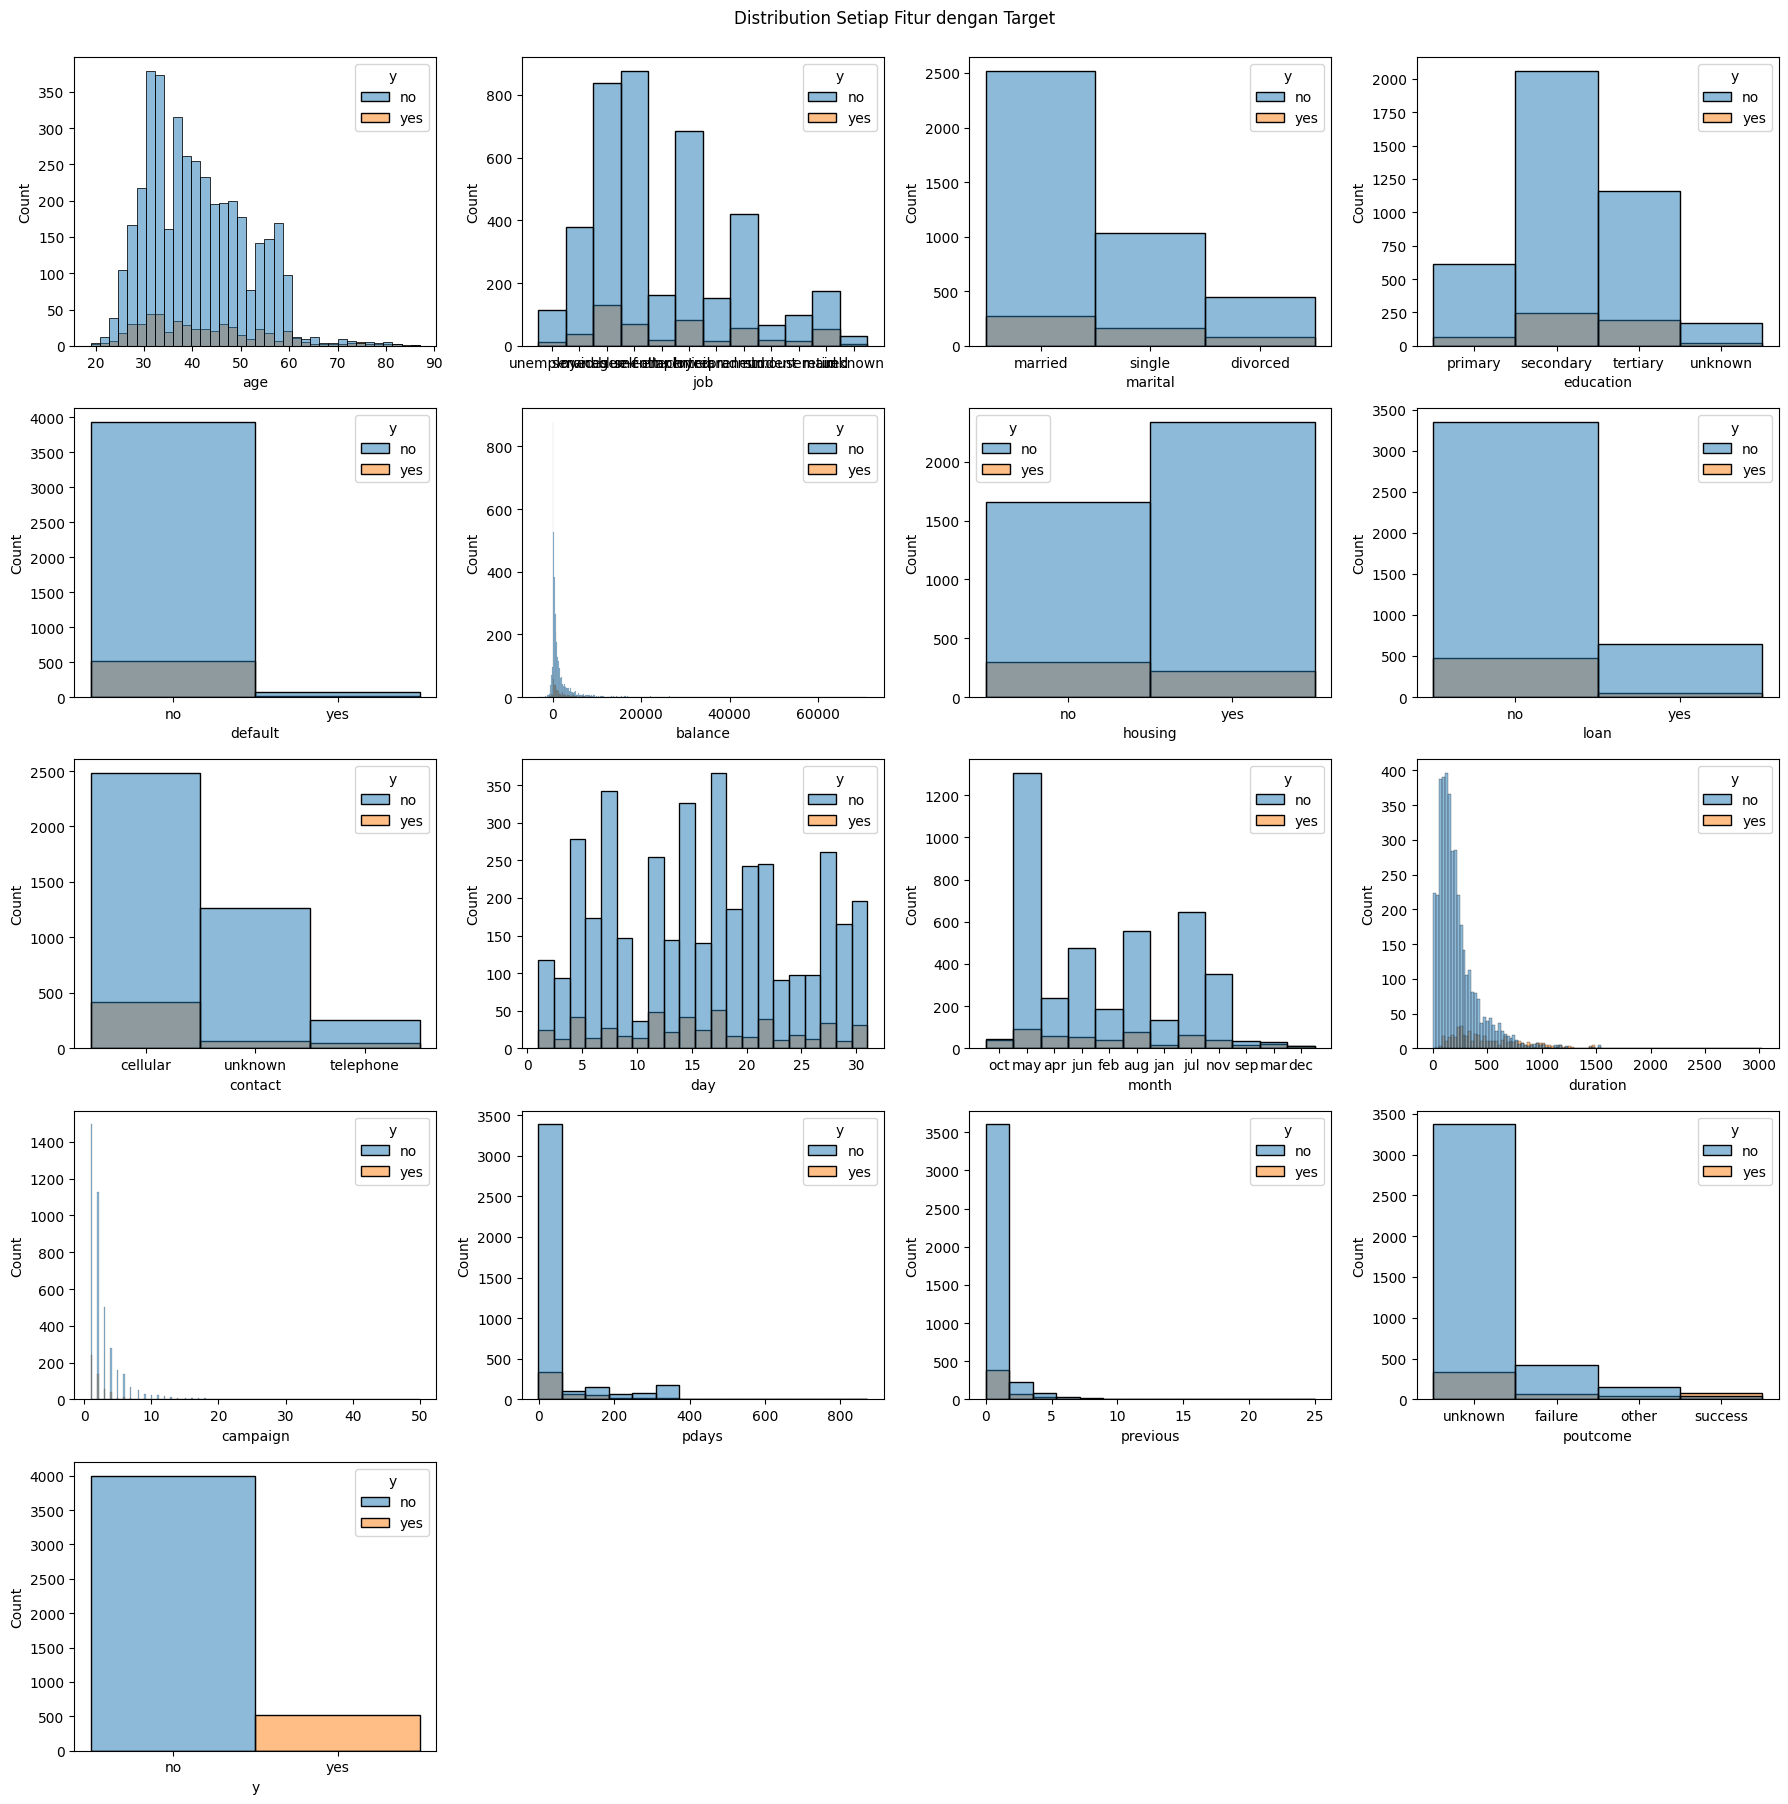

In [850]:
plt.figure(figsize=(18, 18))
for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset['y'])

plt.suptitle("Distribution Setiap Fitur dengan Target", y=1)
plt.tight_layout()
plt.show()

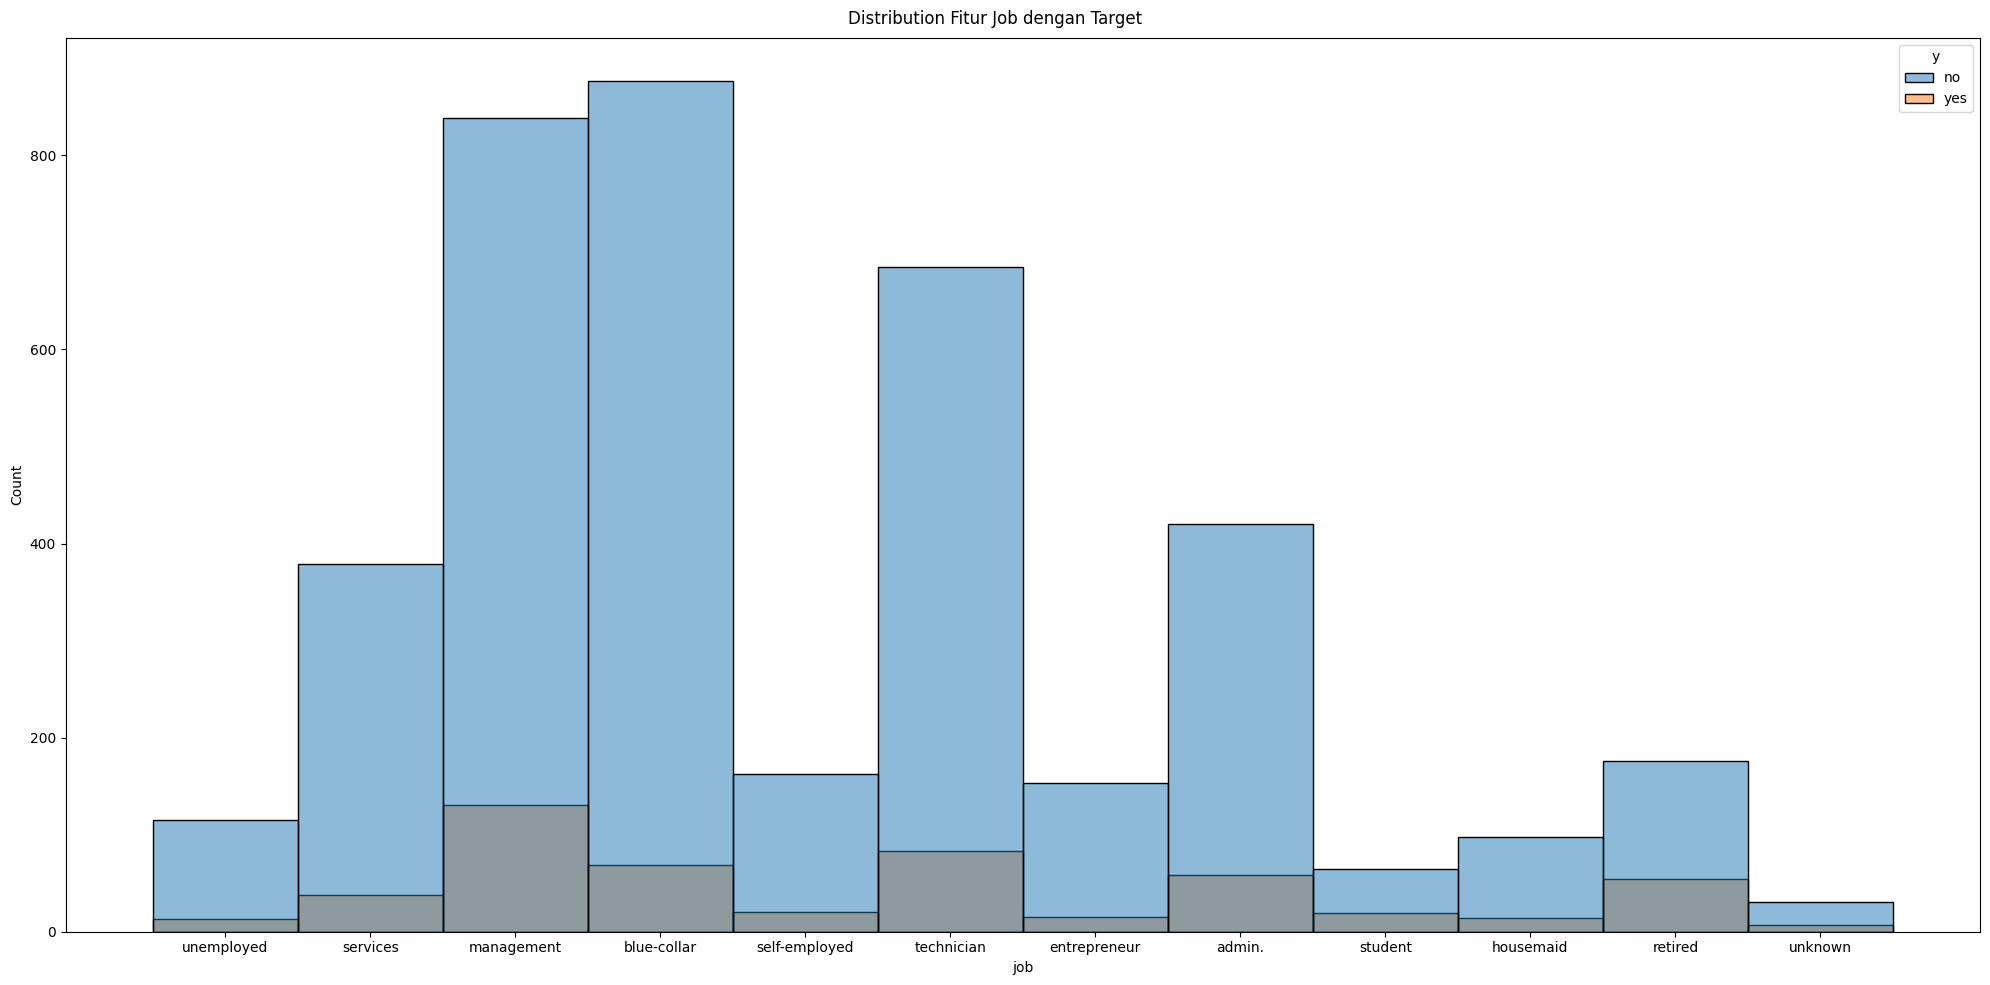

In [851]:
plt.figure(figsize=(20, 10))
sns.histplot(x=dataset["job"], hue=dataset['y'])

plt.suptitle("Distribution Fitur Job dengan Target")
plt.tight_layout()
plt.show()

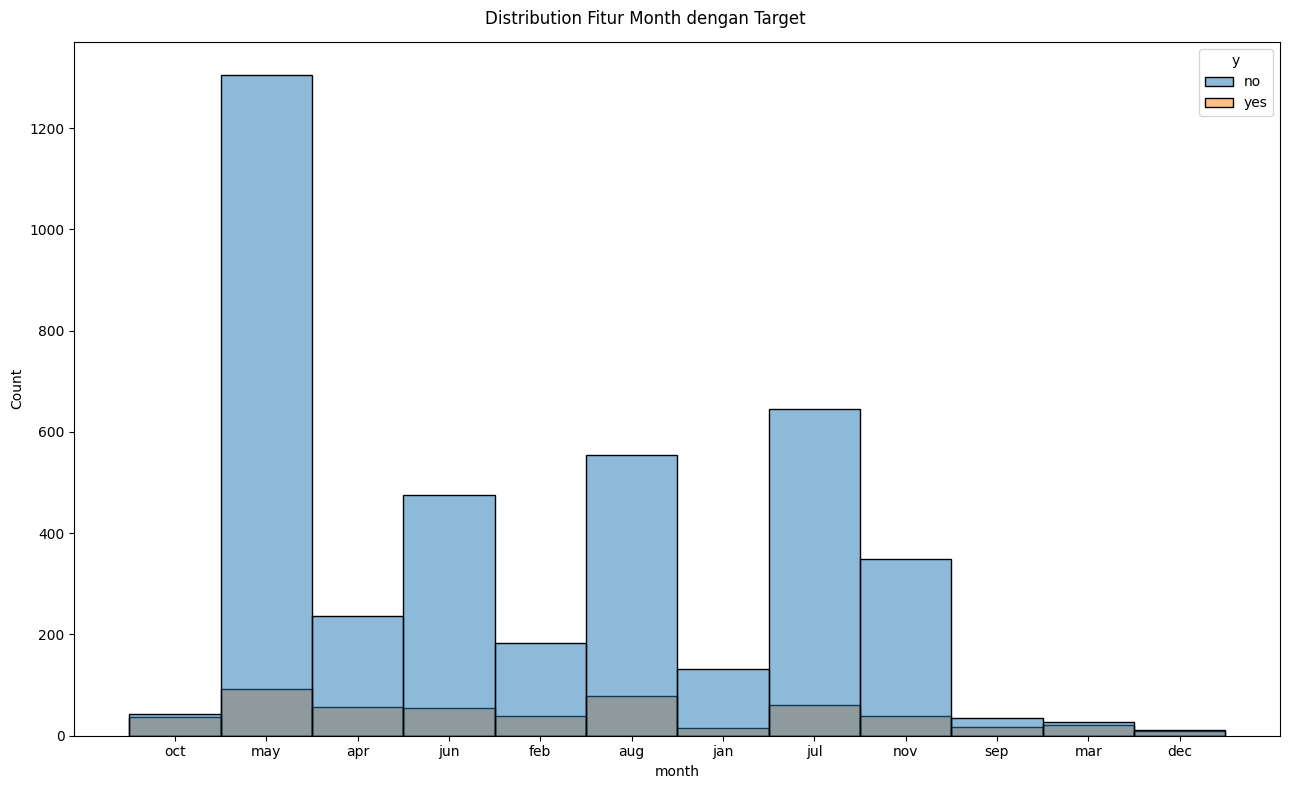

In [852]:
plt.figure(figsize=(13, 8))
sns.histplot(x=dataset["month"], hue=dataset['y'])

plt.suptitle("Distribution Fitur Month dengan Target")
plt.tight_layout()
plt.show()

### 8. Multivariate Analysis

#### *a. Inspeksi Distribusi Data pada Dataset*

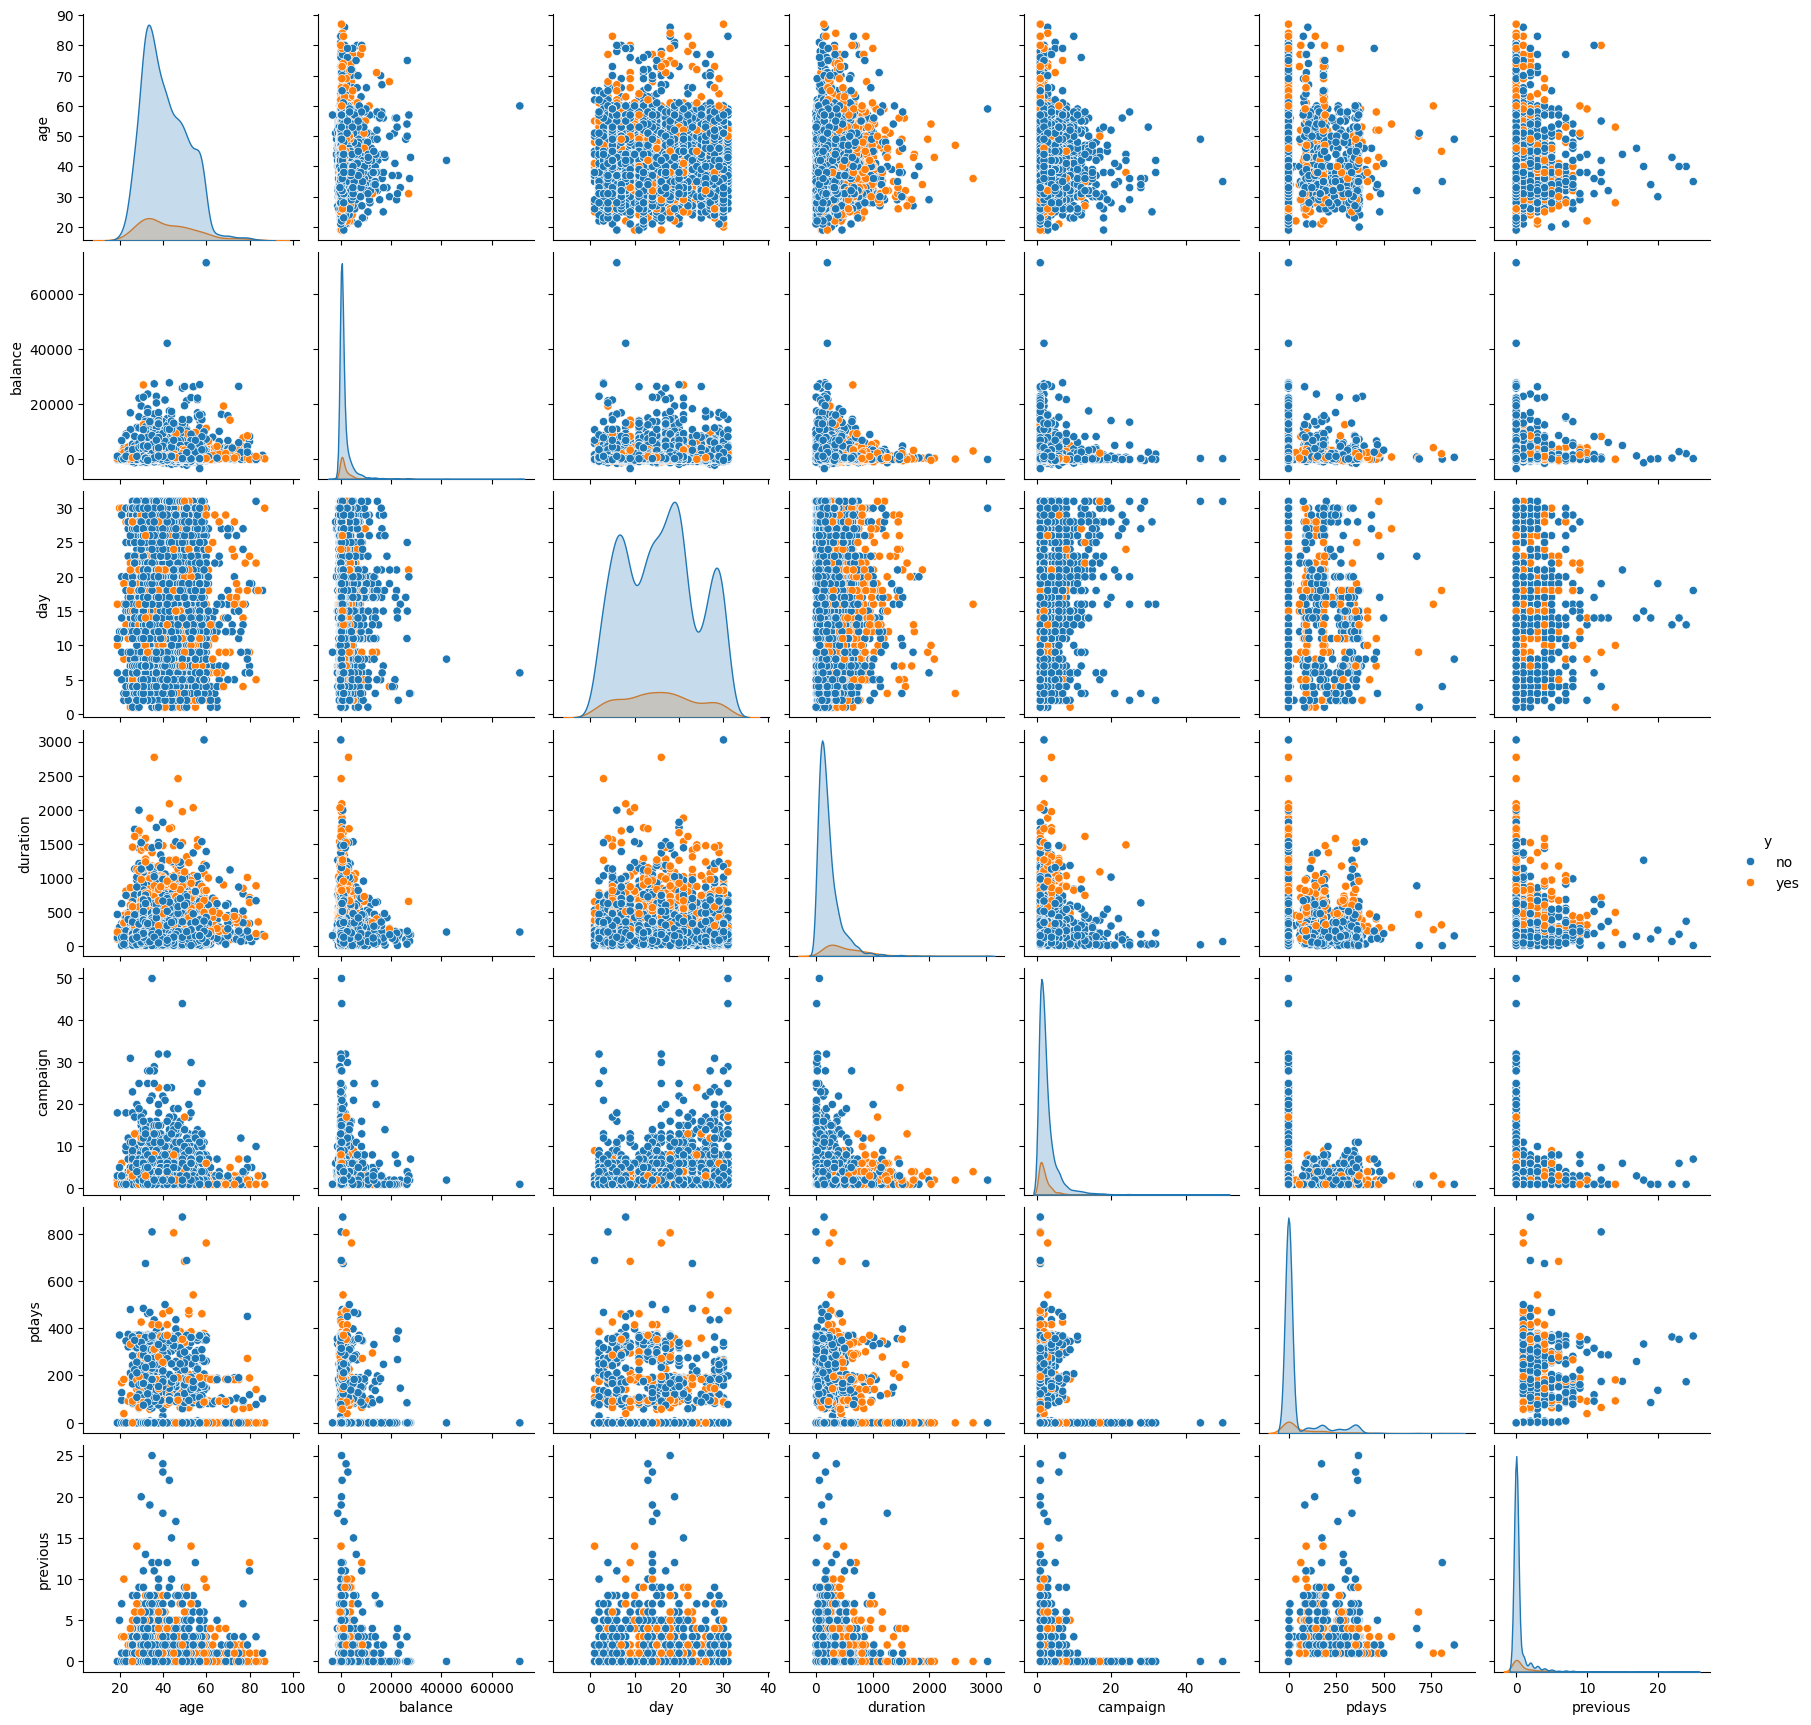

In [853]:
sns.pairplot(dataset, hue="y")

### 9. Dataset Sementara

#### *a. Copy Datset Master*

In [854]:
dataset_copy = dataset.copy()

#### *b. Fitur Baru `Month Difference`*

In [855]:
month_order = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

def month_difference(month):
    if pd.isna(month):
        return None
    dec_index = month_order.index("dec")
    month_index = month_order.index(month)
    return (dec_index - month_index) % 12

dataset_copy["month_diff"] = dataset_copy["month"].apply(month_difference)

#### *c. Encoding "yes" & "no" Features*

In [856]:
yes_no_feature = ['loan', 'housing', 'default', 'y']
yes_no_map = {'yes': 1, 'no': 0}
dataset_copy[yes_no_feature] = dataset_copy[yes_no_feature].replace(yes_no_map)

C:\Users\RyzQ\AppData\Local\Temp\ipykernel_35620\13720387.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset_copy[yes_no_feature] = dataset_copy[yes_no_feature].replace(yes_no_map)


#### *d. Encoding Ordinal Features*

In [857]:
ordinal_feature = ['education', 'contact', 'poutcome']

map_education = {'primary': 2, 'unknown': 0, 'tertiary': 1, 'secondary': 3}
map_contact = {'cellular': 2, 'unknown': 0, 'telephone': 1}
map_poutcome = {'success': 3, 'other': 2, 'failure': 1, 'unknown': 0}

dataset_copy[ordinal_feature[0]] = dataset_copy[ordinal_feature[0]].map(map_education)
dataset_copy[ordinal_feature[1]] = dataset_copy[ordinal_feature[1]].map(map_contact)
dataset_copy[ordinal_feature[2]] = dataset_copy[ordinal_feature[2]].map(map_poutcome)

#### *e. Encoding Categroical Features*

In [858]:
dataset_copy['job'] = pd.factorize(dataset_copy['job'])[0]
dataset_copy['marital'] = pd.factorize(dataset_copy['marital'])[0]

#### *f. Inspeksi Ulang Dataset Copy*

In [859]:
dataset_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   age         4521 non-null   int64 
 1   job         4521 non-null   int64 
 2   marital     4521 non-null   int64 
 3   education   4521 non-null   int64 
 4   default     4521 non-null   int64 
 5   balance     4521 non-null   int64 
 6   housing     4521 non-null   int64 
 7   loan        4521 non-null   int64 
 8   contact     4521 non-null   int64 
 9   day         4521 non-null   int64 
 10  month       4521 non-null   object
 11  duration    4521 non-null   int64 
 12  campaign    4521 non-null   int64 
 13  pdays       4521 non-null   int64 
 14  previous    4521 non-null   int64 
 15  poutcome    4521 non-null   int64 
 16  y           4521 non-null   int64 
 17  month_diff  4521 non-null   int64 
dtypes: int64(17), object(1)
memory usage: 635.9+ KB


In [860]:
dataset_copy.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,duration,campaign,pdays,previous,poutcome,y,month_diff
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,4.095775,0.498120,2.128733,0.016810,1422.657819,0.566025,0.152842,1.347711,15.915284,263.961292,2.793630,39.766645,0.542579,0.281132,0.115240,5.833223
std,10.576211,2.602310,0.695471,0.978652,0.128575,3009.638142,0.495676,0.359875,0.901498,8.247667,259.856633,3.109807,100.121124,1.693562,0.678637,0.319347,2.378380
min,19.000000,0.000000,0.000000,0.000000,0.000000,-3313.000000,0.000000,0.000000,0.000000,1.000000,4.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,2.000000,0.000000,1.000000,0.000000,69.000000,0.000000,0.000000,0.000000,9.000000,104.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,4.000000
50%,39.000000,3.000000,0.000000,3.000000,0.000000,444.000000,1.000000,0.000000,2.000000,16.000000,185.000000,2.000000,-1.000000,0.000000,0.000000,0.000000,6.000000
75%,49.000000,5.000000,1.000000,3.000000,0.000000,1480.000000,1.000000,0.000000,2.000000,21.000000,329.000000,3.000000,-1.000000,0.000000,0.000000,0.000000,7.000000
max,87.000000,11.000000,2.000000,3.000000,1.000000,71188.000000,1.000000,1.000000,2.000000,31.000000,3025.000000,50.000000,871.000000,25.000000,3.000000,1.000000,11.000000


### 10. Inspeksi Korelasi

#### *a. Mutual Information*

In [861]:
real_feature = ['education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'month_diff']

def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    probabilities = counts / counts.sum()
    return probabilities

def calculate_entropy(x):
    probabilities = probability_distribution(x)
    entropy_value = -np.sum(probabilities * np.log2(probabilities + 1e-10)) 
    return entropy_value

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True, axis=0)
    prob_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(prob_xy * np.log2(prob_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

fitur = dataset_copy[real_feature]
target = dataset_copy['y']

mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}

mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)

mi_df

,Feature,Mutual Information
2,balance,0.319681
8,duration,0.261403
10,pdays,0.085885
12,poutcome,0.037581
13,month_diff,0.029901
7,month,0.029901
11,previous,0.020732
5,contact,0.016335
6,day,0.013350
3,housing,0.007827


C:\Users\RyzQ\AppData\Local\Temp\ipykernel_35620\3526654630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Feature", y="Mutual Information", palette="viridis")


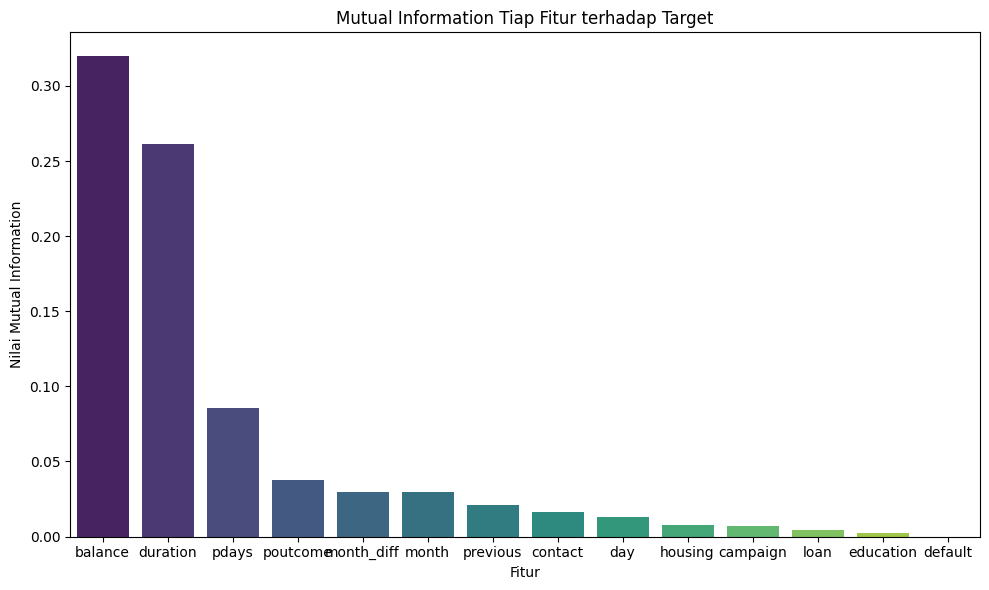

In [862]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df, x="Feature", y="Mutual Information", palette="viridis")

plt.title("Mutual Information Tiap Fitur terhadap Target")
plt.xlabel("Fitur")
plt.ylabel("Nilai Mutual Information")
plt.tight_layout()
plt.show()

kita bisa gunakan MI sebagai asumsi awal, barulah dicek secara menyeluruh sesuai dengan jenis / tipe data fitur

#### *b. Method Kendall untuk Fitur Numerik*

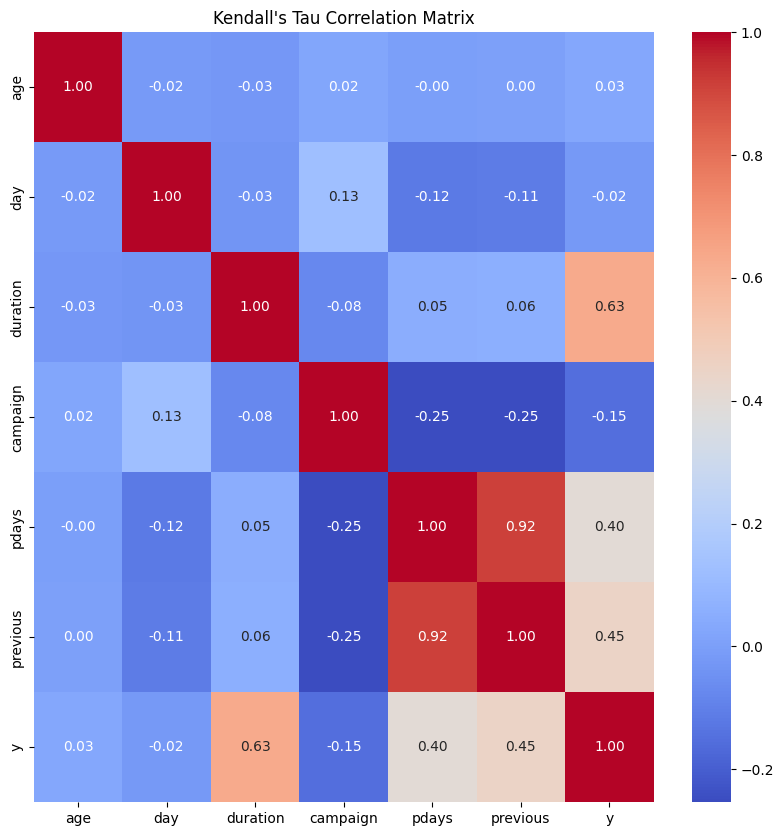

In [863]:
def kendall_tau(x, y):
    n = len(x)
    concordant = 0
    discordant = 0
    
    for i in range(n-1):
        for j in range(i+1, n):
            x_diff = x[i] - x[j]
            y_diff = y[i] - y[j]
            
            if x_diff * y_diff > 0:
                concordant += 1
            elif x_diff * y_diff < 0:
                discordant += 1
    
    if (concordant + discordant) == 0:
        return 0
    return (concordant - discordant) / (concordant + discordant)

fitur_continu = ['age', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y']
corr_matrix = pd.DataFrame(index=fitur_continu, columns=fitur_continu)

for col1 in fitur_continu:
    for col2 in fitur_continu:
        corr_matrix.loc[col1, col2] = kendall_tau(dataset_copy[col1].values, dataset_copy[col2].values)

corr_matrix = corr_matrix.astype(float)

plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, cmap='coolwarm', fmt=".2f", annot=True)
plt.title("Kendall's Tau Correlation Matrix")
plt.show()

#### *c. Chi Square untuk Fitur Kategorikal*

In [864]:
def chi_square_test(data, col1, col2):
    observed = pd.crosstab(data[col1], data[col2])

    total = observed.values.sum()
    row_totals = observed.sum(axis=1).values.reshape(-1, 1)
    col_totals = observed.sum(axis=0).values.reshape(1, -1)

    expected = row_totals @ col_totals / total
    chi_square = ((observed.values - expected) ** 2 / expected).sum()
    dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)

    expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

    print("Tabel Observed:")
    print(observed)

    print("\nTabel Expected:")
    print(expected_df)

    print(f"\nChi-square score: {chi_square:.4f}")
    print(f"Degrees of freedom: {dof}")

    return chi_square, dof, observed, expected_df

chi_square, dof, observed, expected = chi_square_test(dataset_copy, 'marital', 'y')

Tabel Observed:
y           0    1
marital           
0        2520  277
1        1029  167
2         451   77

Tabel Expected:
y                  0           1
marital                         
0        2474.673745  322.326255
1        1058.172971  137.827029
2         467.153285   60.846715

Chi-square score: 19.0301
Degrees of freedom: 2


### 11. Inspeksi Data Outlier

<Axes: ylabel='balance'>

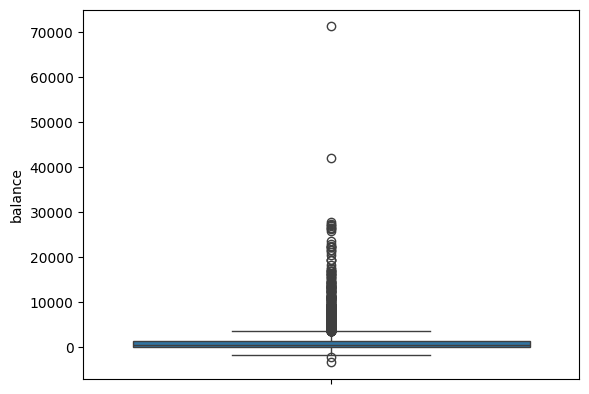

In [865]:
sns.boxplot(dataset_copy['balance'])

## ***B. Feature Selection***

Berdasarkan hasil analisis sebelumnya, kami mengambil fitur:
1. `duration`
2. `pdays`
3. `previous`
4. `poutcome`

In [866]:
feature_cols = ["duration", "pdays", "previous", "poutcome", "marital"]

## ***C. Data Preprocessing***

### 1. Feature Encoding

In [867]:
dataset[ordinal_feature[2]] = dataset[ordinal_feature[2]].map(map_poutcome)
encoded_marital, label_marital = pd.factorize(dataset['marital'])
dataset['marital'] = encoded_marital

### 2. Target Encoding

In [868]:
dataset['y'] = dataset['y'].map(yes_no_map)

## ***D. Splitting Dataset***

Splitting dataset terlebih dahulu menggunakan metode stratified.

In [869]:
def stratified_split(dataset, target_column, training_size=0.8, random_state=42, frac=1):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(frac=frac, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split(dataset, "y")

## ***E. Oversampling***

### 1. SMOTE Oversampling

In [870]:
dataset_training['y'].value_counts()

y
0    3200
1     416
Name: count, dtype: int64

In [871]:
def apply_smote_manual(dataset, target_column, additional_size=None):
    classes = dataset[target_column].value_counts()
    resampled_data = [dataset]
    
    for label, size in classes.items():
        if additional_size and additional_size.get(label, 0) > 0:
            minority_class_data = dataset[dataset[target_column] == label]
            additional_samples = minority_class_data.sample(n=additional_size[label], replace=True, random_state=42)
            resampled_data.append(additional_samples)
    
    final_dataset = pd.concat(resampled_data).sample(frac=1, random_state=42).reset_index(drop=True)
    return final_dataset

additional_samples = {0: 0, 1: 500}  

dataset_training = apply_smote_manual(dataset_training, 'y', additional_samples)

In [872]:
dataset_training['y'].value_counts()

y
0    3200
1     916
Name: count, dtype: int64

## ***E. Feature Target Declaration***

In [873]:
X_train = dataset_training[feature_cols]
X_test = dataset_testing[feature_cols]

y_train = dataset_training["y"]
y_test = dataset_testing["y"]

## ***F. Feature Scaling***

In [874]:
# X_mean = X_train.mean()
# X_std = X_train.std()

# X_train = (X_train - X_mean) / X_std
# X_test = (X_test - X_mean) / X_std

## ***G. Dimension Reduction***

### 1. Principal Component Analysis

In [875]:
def pca_fit(X, n_components):
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean
    cov = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    components = eigenvectors[:, :n_components]

    X_pca = np.dot(X_centered, components)
    explained_variance = eigenvalues[:n_components]
    return X_pca, components, X_mean, explained_variance

def pca_transform(X, components, X_mean):
    X_centered = X - X_mean
    return np.dot(X_centered, components)

### 2. Multiple Correspondence Analysis

In [876]:
def mca_fit(X_cat, n_components):
    X_dummies = pd.get_dummies(X_cat)
    X_matrix = X_dummies.to_numpy()
    
    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()
    
    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)

    U, S, VT = np.linalg.svd(Z, full_matrices=False)
    X_mca = U[:, :n_components] * S[:n_components]
    components = VT[:n_components, :]
    
    return X_mca, components, X_dummies.columns

def mca_transform(X_cat, components, dummy_columns):
    X_dummies = pd.get_dummies(X_cat)
    X_dummies = X_dummies.reindex(columns=dummy_columns, fill_value=0)
    
    X_matrix = X_dummies.to_numpy()
    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()
    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)
    
    X_proj = Z @ components.T
    return X_proj

### 3. Factor Analysis of Mixed Data

In [877]:
def famd_fit_auto(df, n_components):
    num_cols = df.select_dtypes(include=["float"]).columns
    cat_cols = df.select_dtypes(include=["int", "object", "category"]).columns

    X_num = df[num_cols].to_numpy()
    X_cat = df[cat_cols]

    X_pca, pca_components, pca_mean, _ = pca_fit(X_num, n_components)
    X_mca, mca_components, dummy_columns = mca_fit(X_cat, n_components)

    X_famd = np.hstack([X_pca, X_mca])

    return {
        "X_famd": X_famd,
        "pca_components": pca_components,
        "pca_mean": pca_mean,
        "mca_components": mca_components,
        "dummy_columns": dummy_columns,
        "num_cols": num_cols,
        "cat_cols": cat_cols
    }

def famd_transform_auto(df, model):
    X_num = df[model["num_cols"]].to_numpy()
    X_cat = df[model["cat_cols"]]

    X_pca = pca_transform(X_num, model["pca_components"], model["pca_mean"])
    X_mca = mca_transform(X_cat, model["mca_components"], model["dummy_columns"])

    return np.hstack([X_pca, X_mca])


In [878]:
famd_model = famd_fit_auto(X_train, n_components=2)
X_train_famd = famd_model["X_famd"]
X_test_famd = famd_transform_auto(X_test, famd_model)

famd_df = pd.DataFrame(X_train_famd, columns=["Dim1", "Dim2"])
famd_df["target"] = y_train.values

### 4. Visualisasi Data Training Setelah FAMD

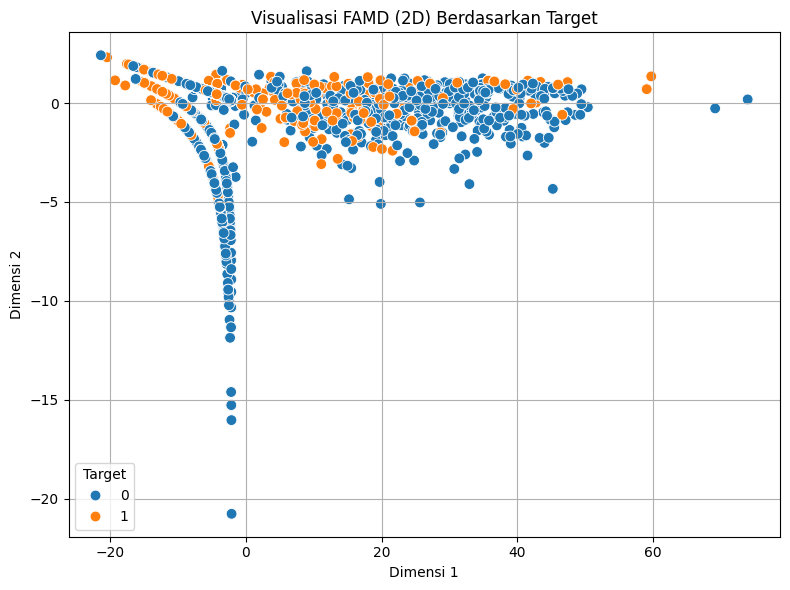

In [879]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=famd_df, x="Dim1", y="Dim2", hue="target", palette="tab10", s=60)

plt.title("Visualisasi FAMD (2D) Berdasarkan Target")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.legend(title="Target")
plt.grid(True)
plt.tight_layout()
plt.show()

# **III. Modeling**

## ***A. Model Application***

### 1. Model dengan Class

In [880]:
class KNN:
    def __init__(self, k=5, p=2):
        self.k = k
        self.p = p

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def minkowski_distance(self, a, b):
        return np.sum(np.abs(a - b) ** self.p) ** (1 / self.p)

    def predict(self, X):
        X_test = X
        distances = np.zeros((X_test.shape[0], self.X_train.shape[0]))

        for i, test_point in enumerate(X_test):
            for j, train_point in enumerate(self.X_train):
                distances[i, j] = self.minkowski_distance(test_point, train_point)

        nearest_neighbors_indices = np.argsort(distances, axis=1)[:, :self.k]
        neighbors = np.array(self.y_train)[nearest_neighbors_indices]

        y_pred = []
        for neighbor_classes in neighbors:
            classes, counts = np.unique(neighbor_classes, return_counts=True)
            predicted_class = classes[np.argmax(counts)]
            y_pred.append(predicted_class)

        return np.array(y_pred)

    def plot_neighbors(self, input_point, y_train, zoom=False):
        distances = np.array([self.minkowski_distance(input_point, train_point) for train_point in self.X_train])
        nearest_neighbors_indices = np.argsort(distances)[:self.k]

        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(self.X_train[:, 0], self.X_train[:, 1], c=y_train, cmap="coolwarm", alpha=0.7, label="Training Data")
        plt.colorbar(scatter, label="Class")

        plt.scatter(input_point[0], input_point[1], c="yellow", edgecolors="black", s=200, marker="*", label="Input Data")

        cmap = plt.cm.coolwarm
        norm = plt.Normalize(vmin=0, vmax=1)

        for i, idx in enumerate(nearest_neighbors_indices):
            neighbor_point = self.X_train[idx]
            color = cmap(norm(y_train[idx])) 
            label = "Nearest Neighbors" if i == 0 else None
            plt.scatter(neighbor_point[0], neighbor_point[1], facecolors=color, edgecolors="black", 
                        s=150, linewidth=2, label=label)
            plt.plot([input_point[0], neighbor_point[0]], 
                     [input_point[1], neighbor_point[1]], 
                     "black", linestyle="dashed", alpha=0.5)
            plt.text(neighbor_point[0]+0.01, neighbor_point[1]+0.01, f"{i+1}", fontsize=9, color="black")

        plt.xlabel("Dim 1 (FAMD)")
        plt.ylabel("Dim 2 (FAMD)")
        plt.title("FAMD Scatter Plot dengan Input dan K Nearest Neighbors")
        plt.legend()
        plt.grid(True)

        if zoom:
            all_x = [input_point[0]] + [self.X_train[idx][0] for idx in nearest_neighbors_indices]
            all_y = [input_point[1]] + [self.X_train[idx][1] for idx in nearest_neighbors_indices]

            x_padding = (max(all_x) - min(all_x)) * 3.5
            y_padding = (max(all_y) - min(all_y)) * 3.5

            plt.xlim(min(all_x) - x_padding, max(all_x) + x_padding)
            plt.ylim(min(all_y) - y_padding, max(all_y) + y_padding)

            print("Label Tetangga Terdekat:")
            for i, idx in enumerate(nearest_neighbors_indices):
                print(f"Tetangga ke-{i+1}: Label = {y_train[idx]}")

        plt.show()

### 2. Rule of Thumb

In [881]:
rule_of_thumb = round(np.sqrt(len(X_train_famd)))
rule_of_thumb

64

### 3. K Cross Validation

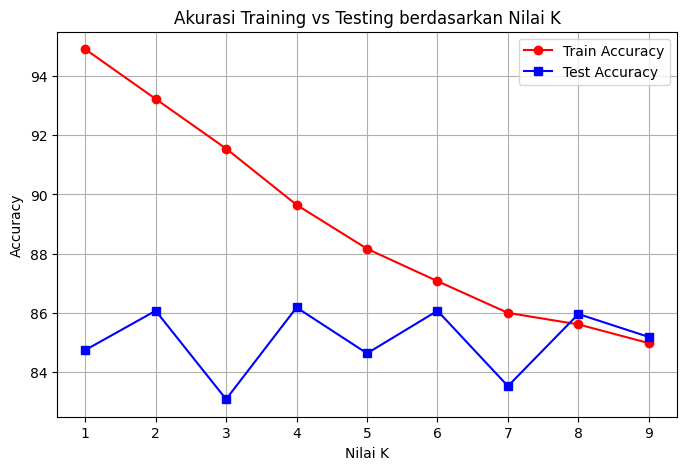

In [882]:
train_accuracies = []
test_accuracies = []
k_values = range(1, 10)

for k in k_values:
    model = KNN(k=k, p=1)
    model.fit(X_train_famd, y_train)
    y_train_pred = model.predict(X_train_famd)
    y_test_pred = model.predict(X_test_famd)

    train_accuracy = np.mean(y_train_pred == y_train) * 100
    test_accuracy = np.mean(y_test_pred == y_test) * 100

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker='o', label='Train Accuracy', color='red')
plt.plot(k_values, test_accuracies, marker='s', label='Test Accuracy', color='blue')
plt.xlabel('Nilai K')
plt.ylabel('Accuracy')
plt.title('Akurasi Training vs Testing berdasarkan Nilai K')
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()

### 4. Elbow Method

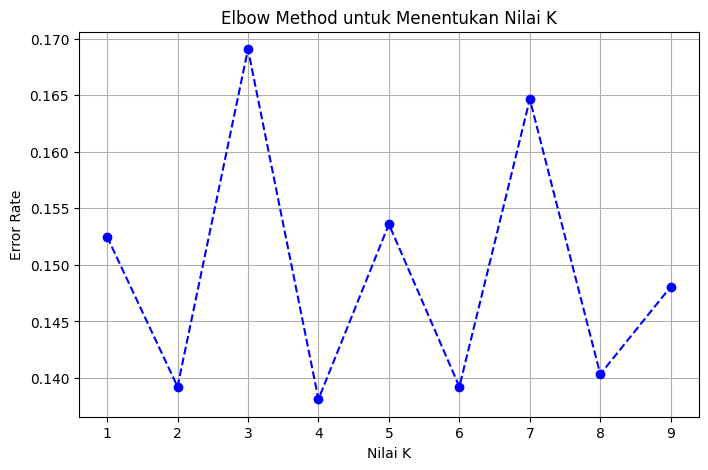

In [883]:
def error_rate(y_true, y_pred):
    return np.sum(y_true != y_pred) / len(y_true)

k_values = range(1, 10)
errors = []

for k in k_values:
    knn = KNN(k=k, p=1)
    knn.fit(X_train_famd, y_train)
    y_pred = knn.predict(X_test_famd)
    error = error_rate(y_test, y_pred)
    errors.append(error)

plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker='o', linestyle='dashed', color='b')
plt.xlabel('Nilai K')
plt.ylabel('Error Rate')
plt.title('Elbow Method untuk Menentukan Nilai K')
plt.xticks(k_values)
plt.grid()
plt.show()

### 5. Pengaplikasian Model

In [884]:
model = KNN(k=9, p=2)
model.fit(X_train_famd, y_train)
y_pred_train = model.predict(X_train_famd)
y_pred_test = model.predict(X_test_famd)

## ***B. Hasil Prediksi***

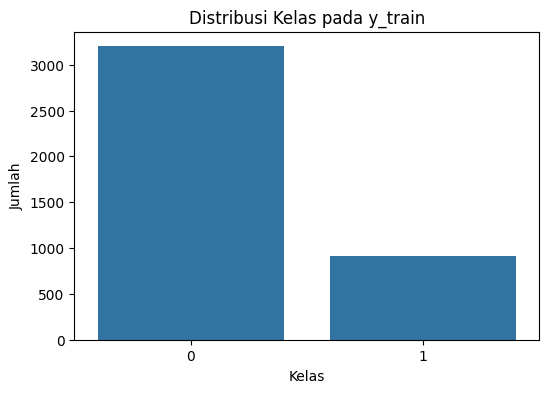

In [885]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title('Distribusi Kelas pada y_train')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.show()

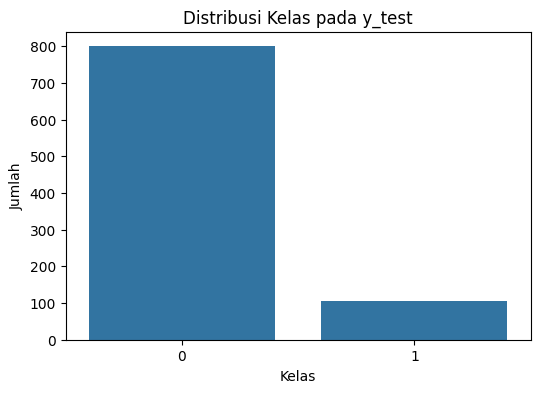

In [886]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_test)
plt.title('Distribusi Kelas pada y_test')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.show()

### 1. Training Model

In [887]:
y_pred_train

array([0, 0, 0, ..., 0, 0, 0])

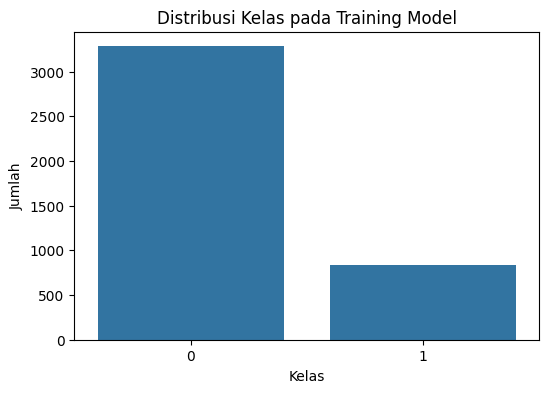

In [888]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_pred_train)
plt.title('Distribusi Kelas pada Training Model')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.show()

### 2. Testing Model

In [889]:
y_pred_test

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

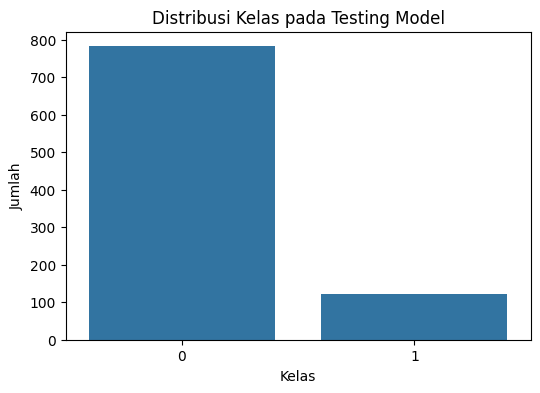

In [890]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_pred_test)
plt.title('Distribusi Kelas pada Testing Model')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.show()

## ***C. Visualisasi Model***

### 1. Uji Coba Data Baru

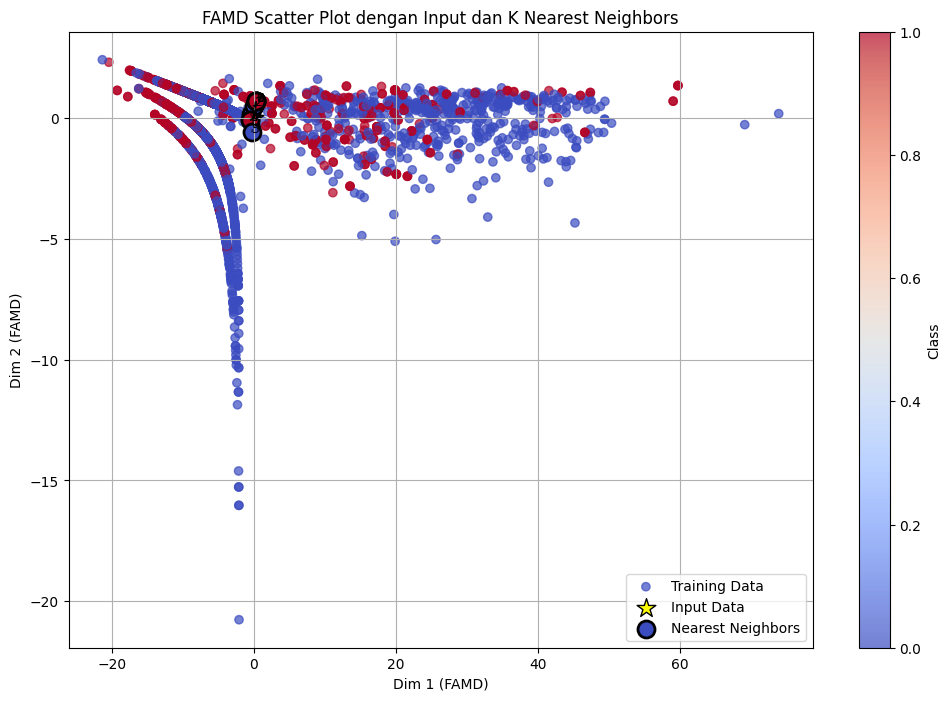

In [891]:
input_data = [900, 18, 3, 2, 2]
input_df = pd.DataFrame([input_data], columns=feature_cols)
input_famd = famd_transform_auto(input_df, famd_model)[0] 
model.plot_neighbors(input_famd, y_train, zoom=False)

Label Tetangga Terdekat:
Tetangga ke-1: Label = 0
Tetangga ke-2: Label = 0
Tetangga ke-3: Label = 1
Tetangga ke-4: Label = 1
Tetangga ke-5: Label = 0
Tetangga ke-6: Label = 1
Tetangga ke-7: Label = 1
Tetangga ke-8: Label = 1
Tetangga ke-9: Label = 1


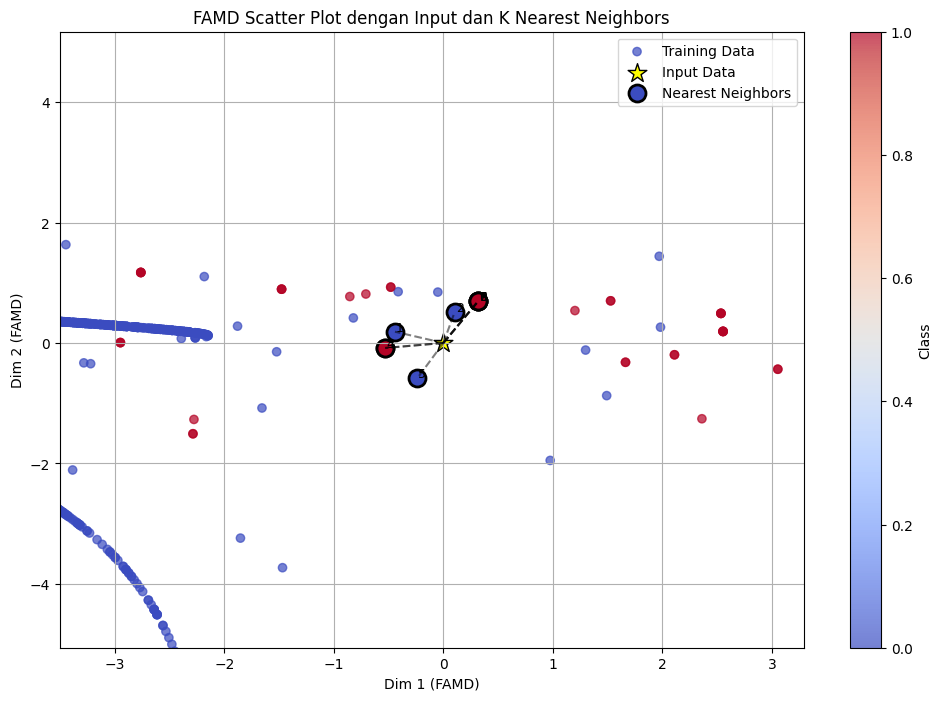

In [892]:
model.plot_neighbors(input_famd, y_train, zoom=True)

Pada visualisasi nampak hanya 5 yang tertangkap karena ada data poin yang overlap antara satu sama lain, sehingga solusinya adalah diprint label dari neighbour terdekat.

### 2. Reverse Map untuk Visualisasi

In [893]:
def reverse_mapping(mapping):
    return {v: k for k, v in mapping.items()}

reverse_map_poutcome = reverse_mapping(map_poutcome)
reverse_map_yes_no_map = reverse_mapping(yes_no_map)

In [894]:
dataset['y'] = dataset['y'].map(reverse_map_yes_no_map)
dataset['poutcome'] = dataset['poutcome'].map(reverse_map_poutcome)
dataset['marital'] = label_marital[dataset['marital']]

### 3. Distribusi Hasil Prediksi

In [895]:
data_pred = pd.DataFrame({"Prediksi": y_pred_test, "Aktual": y_test})
data_pred.to_csv("data_pred")
data_pred

,Prediksi,Aktual
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
900,0,1
901,0,1
902,0,1
903,1,1


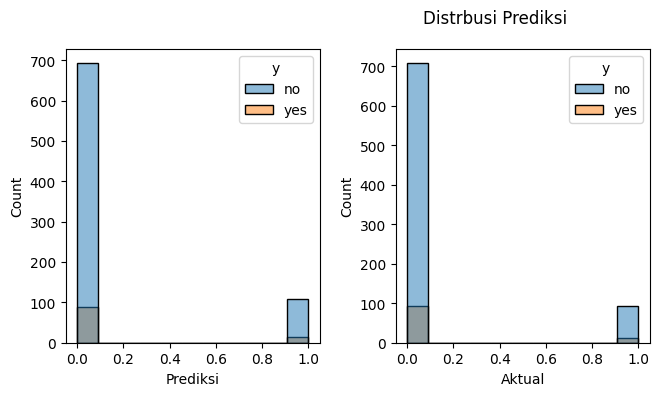

In [896]:
plt.figure(figsize=(10, 4))
for i, col in enumerate(data_pred):
    plt.subplot(1, 3, i+1)
    sns.histplot(x=data_pred[col], hue=dataset['y'])

plt.suptitle("Distrbusi Prediksi")
plt.tight_layout()
plt.show()

### 4. Confusion Matrix

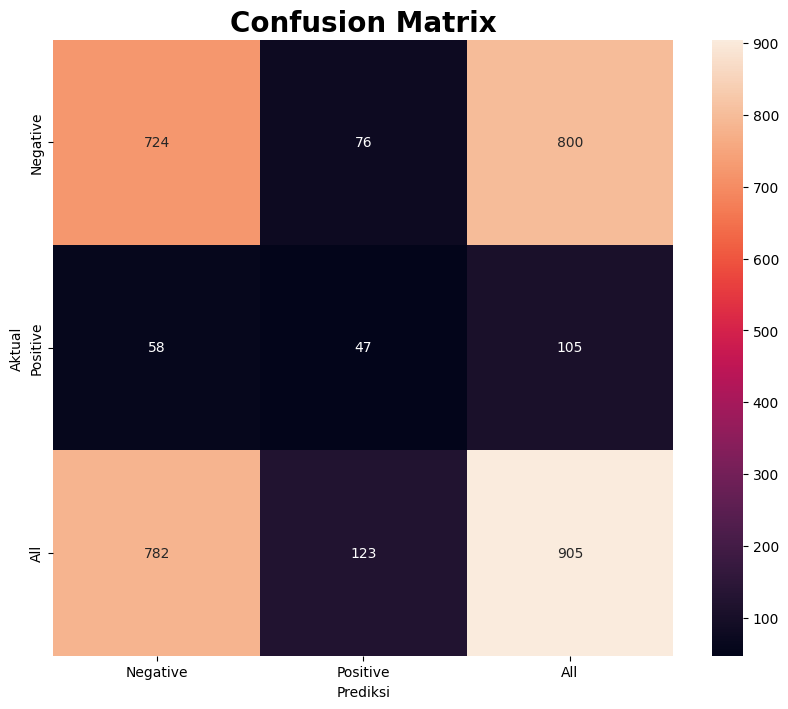

,Negative,Positive,All
Negative,724,76,800
Positive,58,47,105
All,782,123,905


In [897]:
data_confusion = pd.crosstab(y_test, y_pred_test, margins=True)
data_confusion.columns = ['Negative', 'Positive', 'All']
data_confusion.index = ['Negative', 'Positive', 'All']

plt.figure(figsize=(10, 8))
plt.title('Confusion Matrix', size=20, weight='bold')
sns.heatmap(data_confusion, annot=True, fmt='d')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

display(data_confusion)

### 5. Analisis Korelasi Fitur dengan Fitur

Kami juga mencari tahu korelasi fitur yang kami aplikasikan ke model dengan fitur yang ada pada dataset.

#### *a. Fitur Numerik*

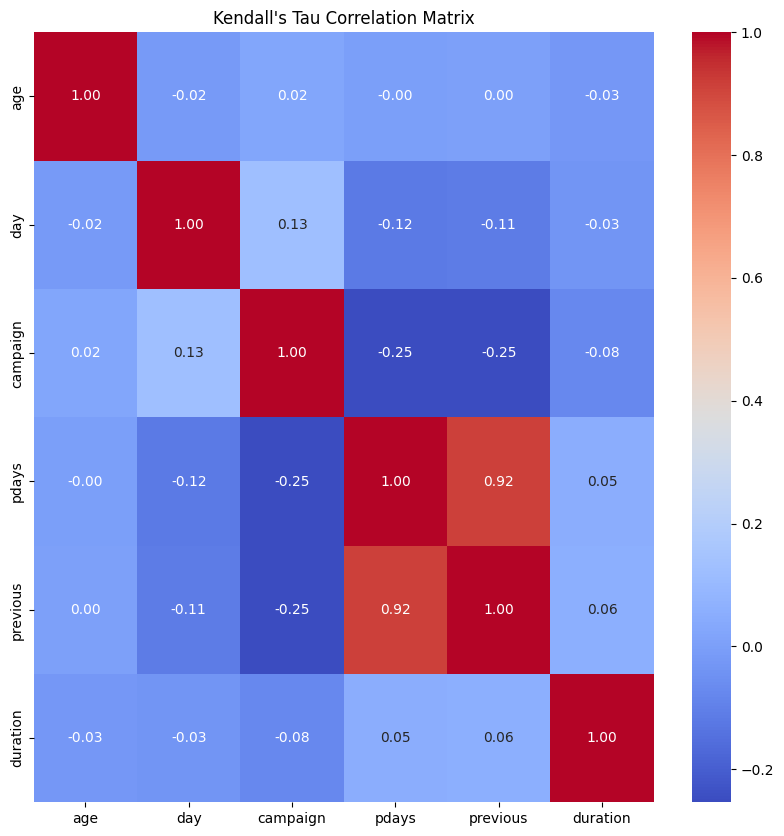

In [898]:
fitur_continu = ['age', 'day', 'campaign', 'pdays', 'previous', 'duration'] # dan fitur fitur lain yang numerik
corr_matrix = pd.DataFrame(index=fitur_continu, columns=fitur_continu)

for col1 in fitur_continu:
    for col2 in fitur_continu:
        corr_matrix.loc[col1, col2] = kendall_tau(dataset_copy[col1].values, dataset_copy[col2].values)

corr_matrix = corr_matrix.astype(float)

plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, cmap='coolwarm', fmt=".2f", annot=True)
plt.title("Kendall's Tau Correlation Matrix")
plt.show()

#### *b. Fitur `Poutcome`*

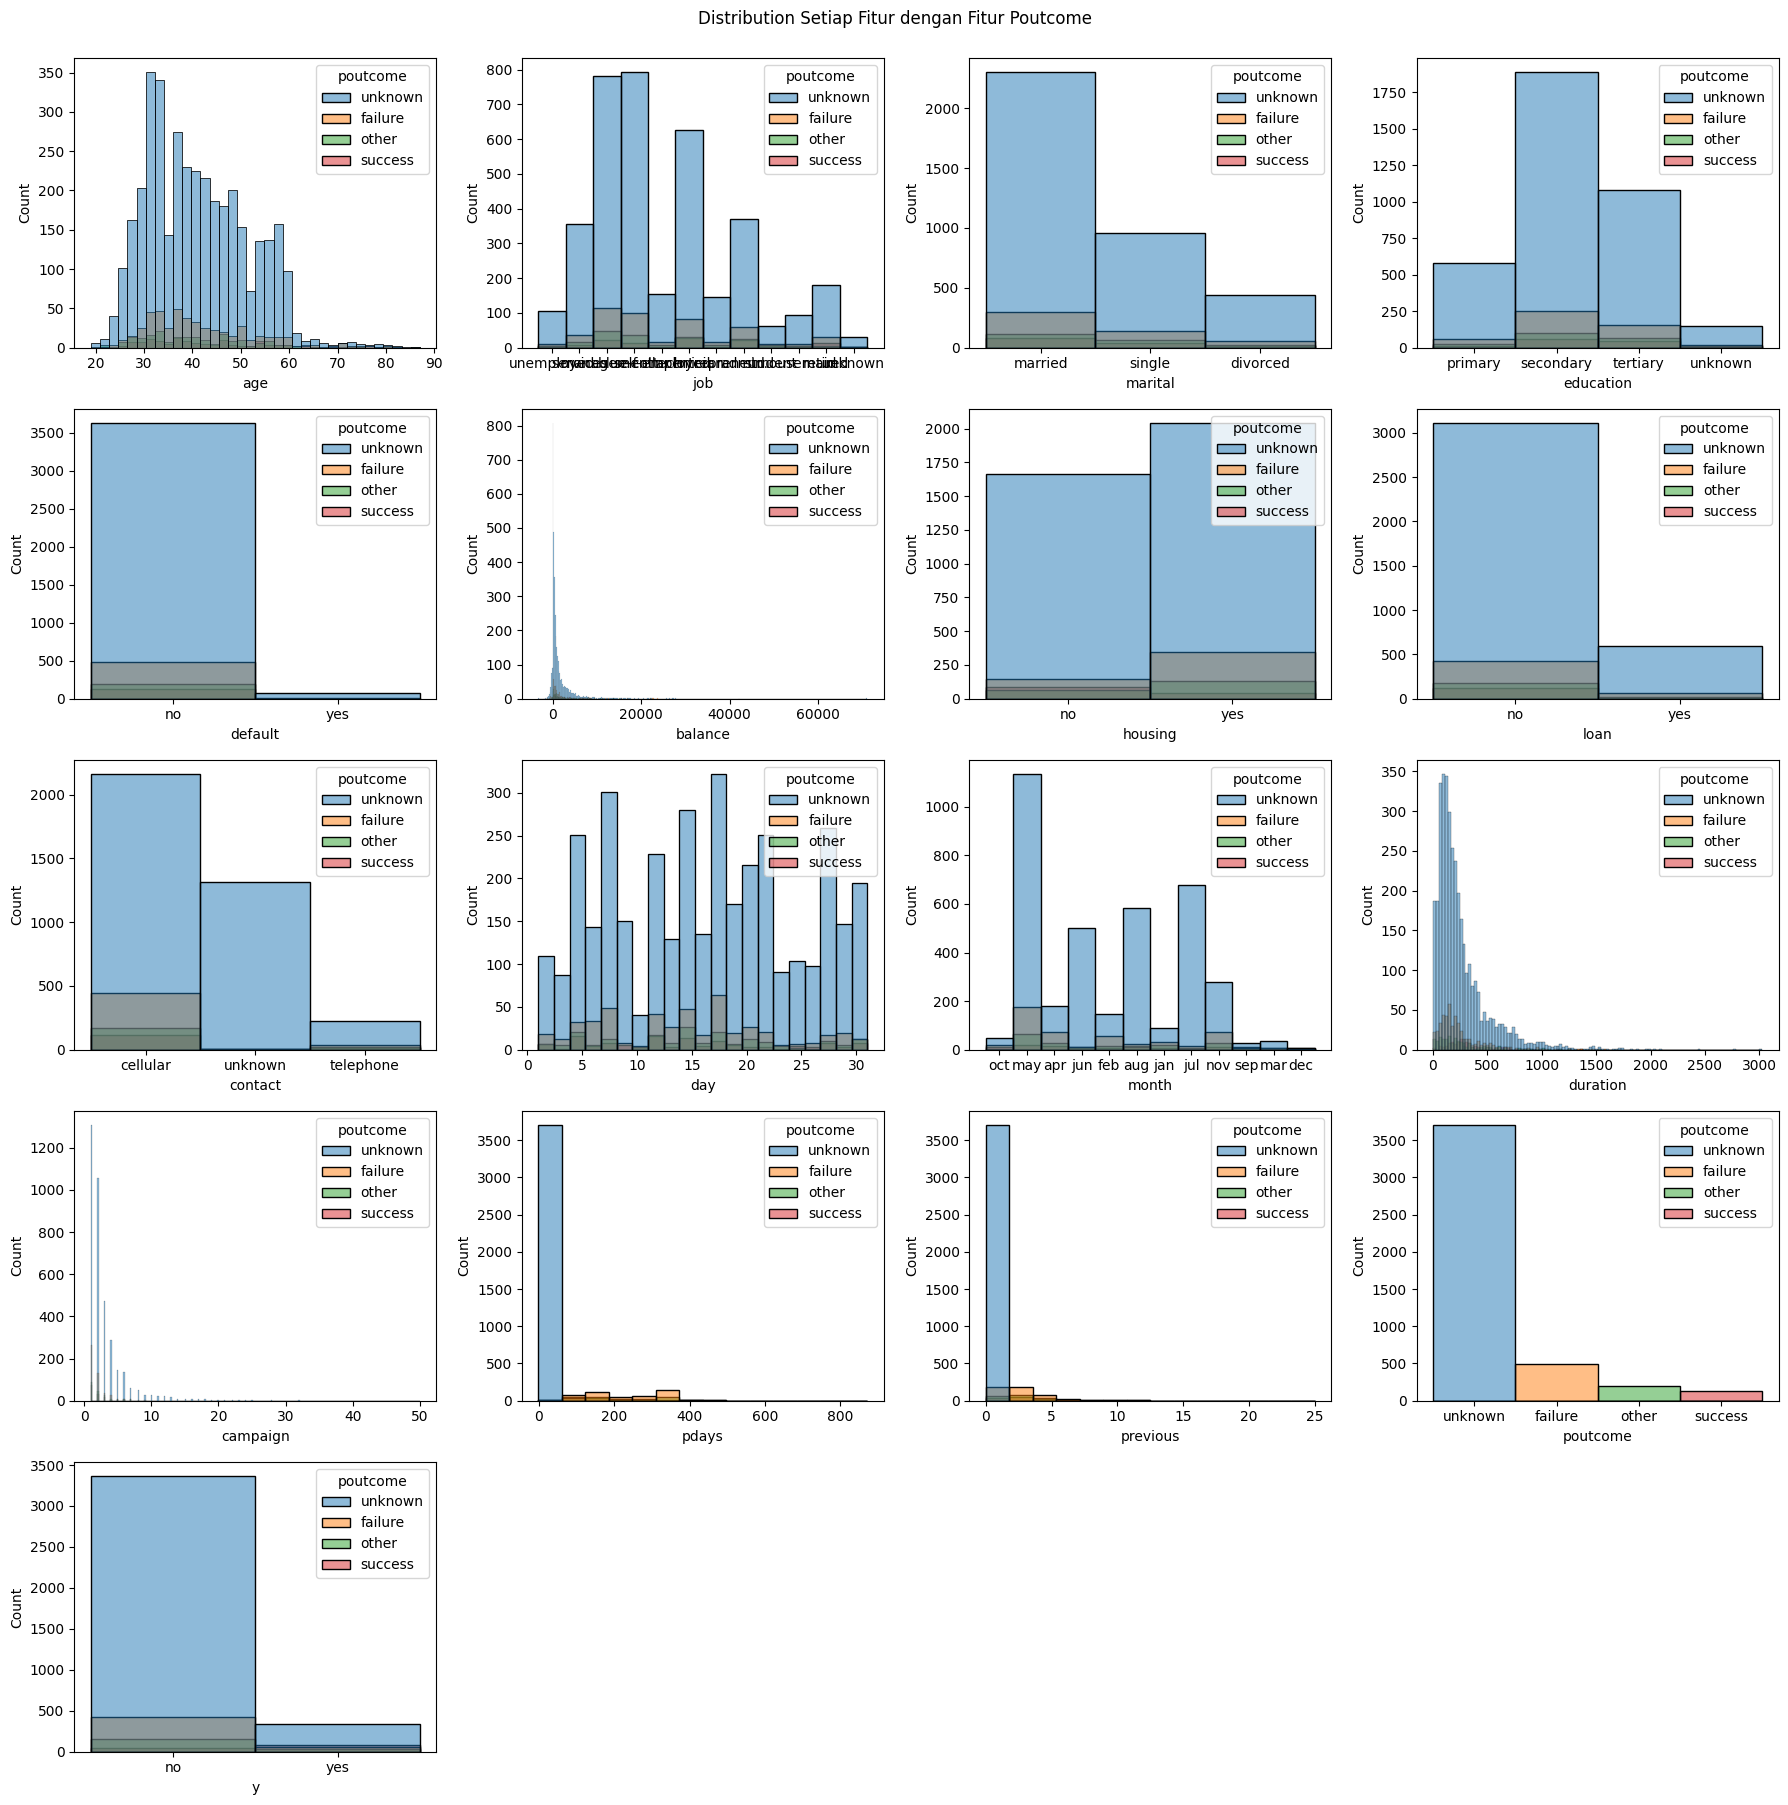

In [899]:
plt.figure(figsize=(18, 18))
for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset['poutcome'])

plt.suptitle("Distribution Setiap Fitur dengan Fitur Poutcome", y=1)
plt.tight_layout()
plt.show()

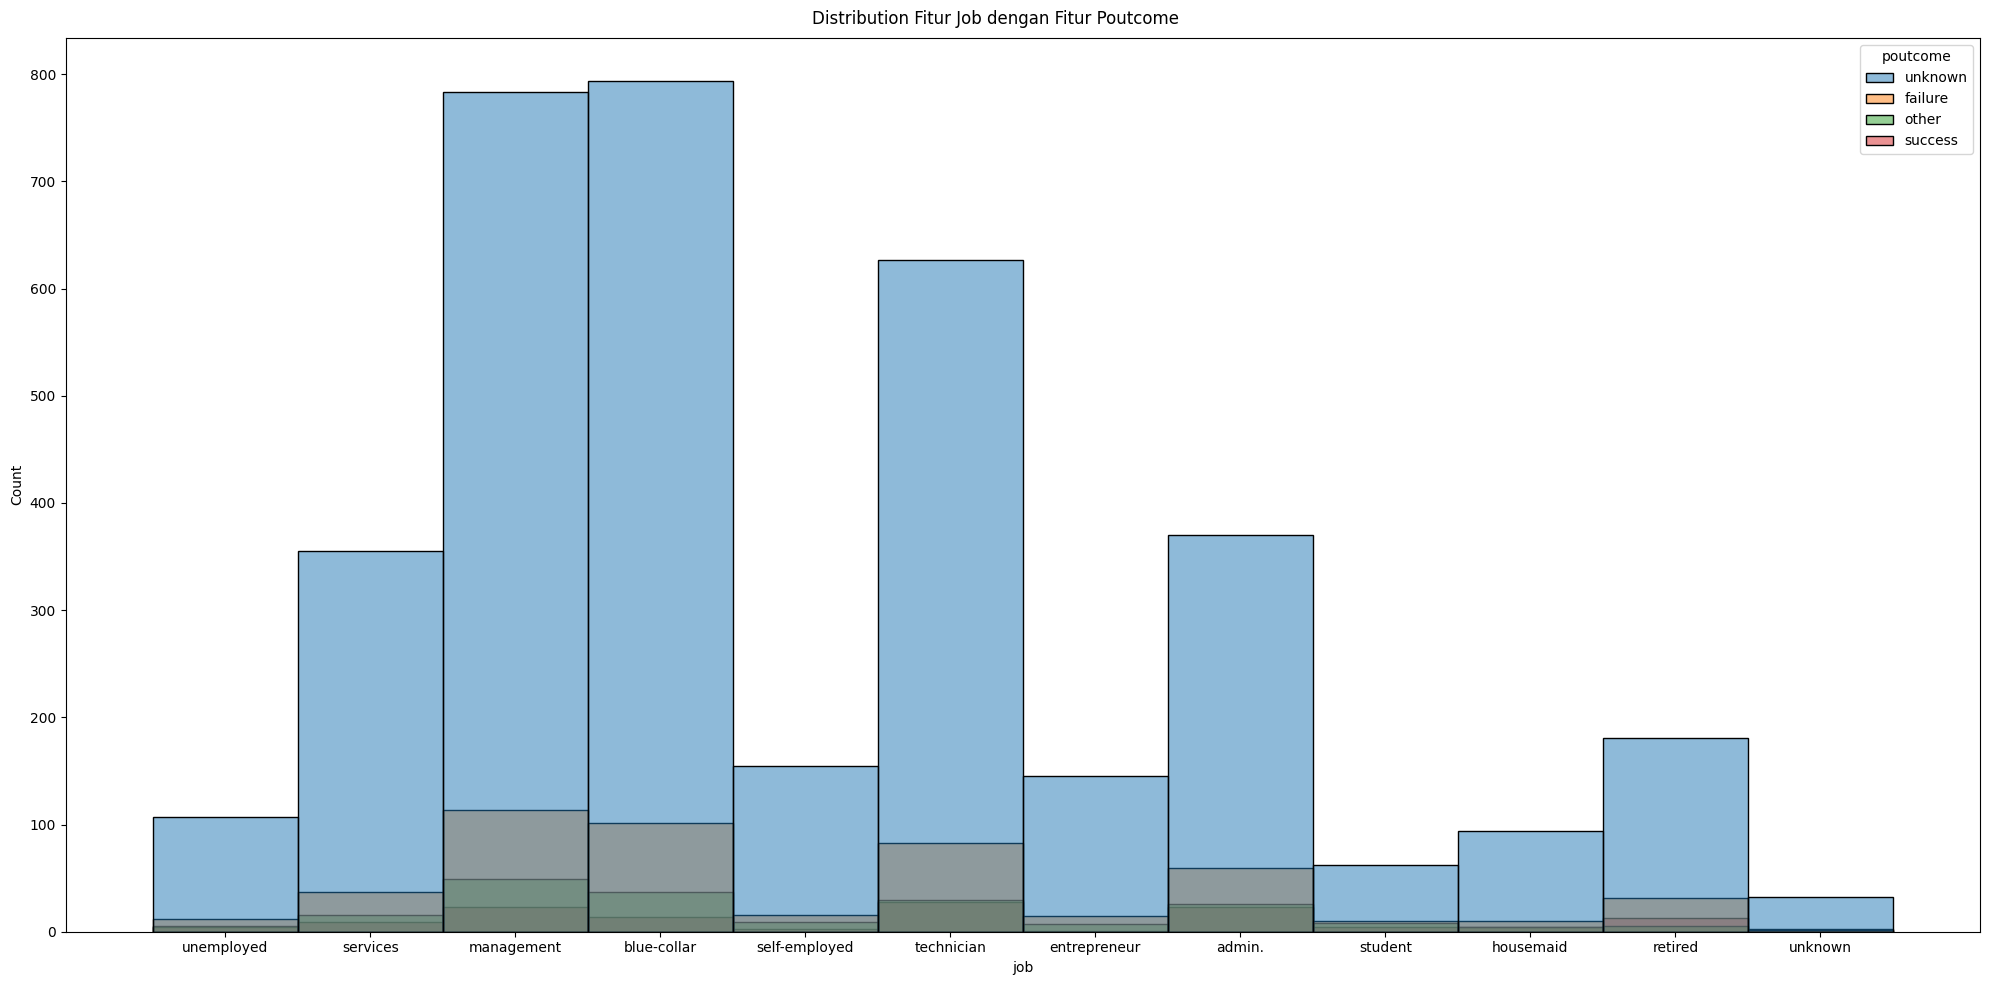

In [900]:
plt.figure(figsize=(20, 10))
sns.histplot(x=dataset["job"], hue=dataset['poutcome'])

plt.suptitle("Distribution Fitur Job dengan Fitur Poutcome")
plt.tight_layout()
plt.show()

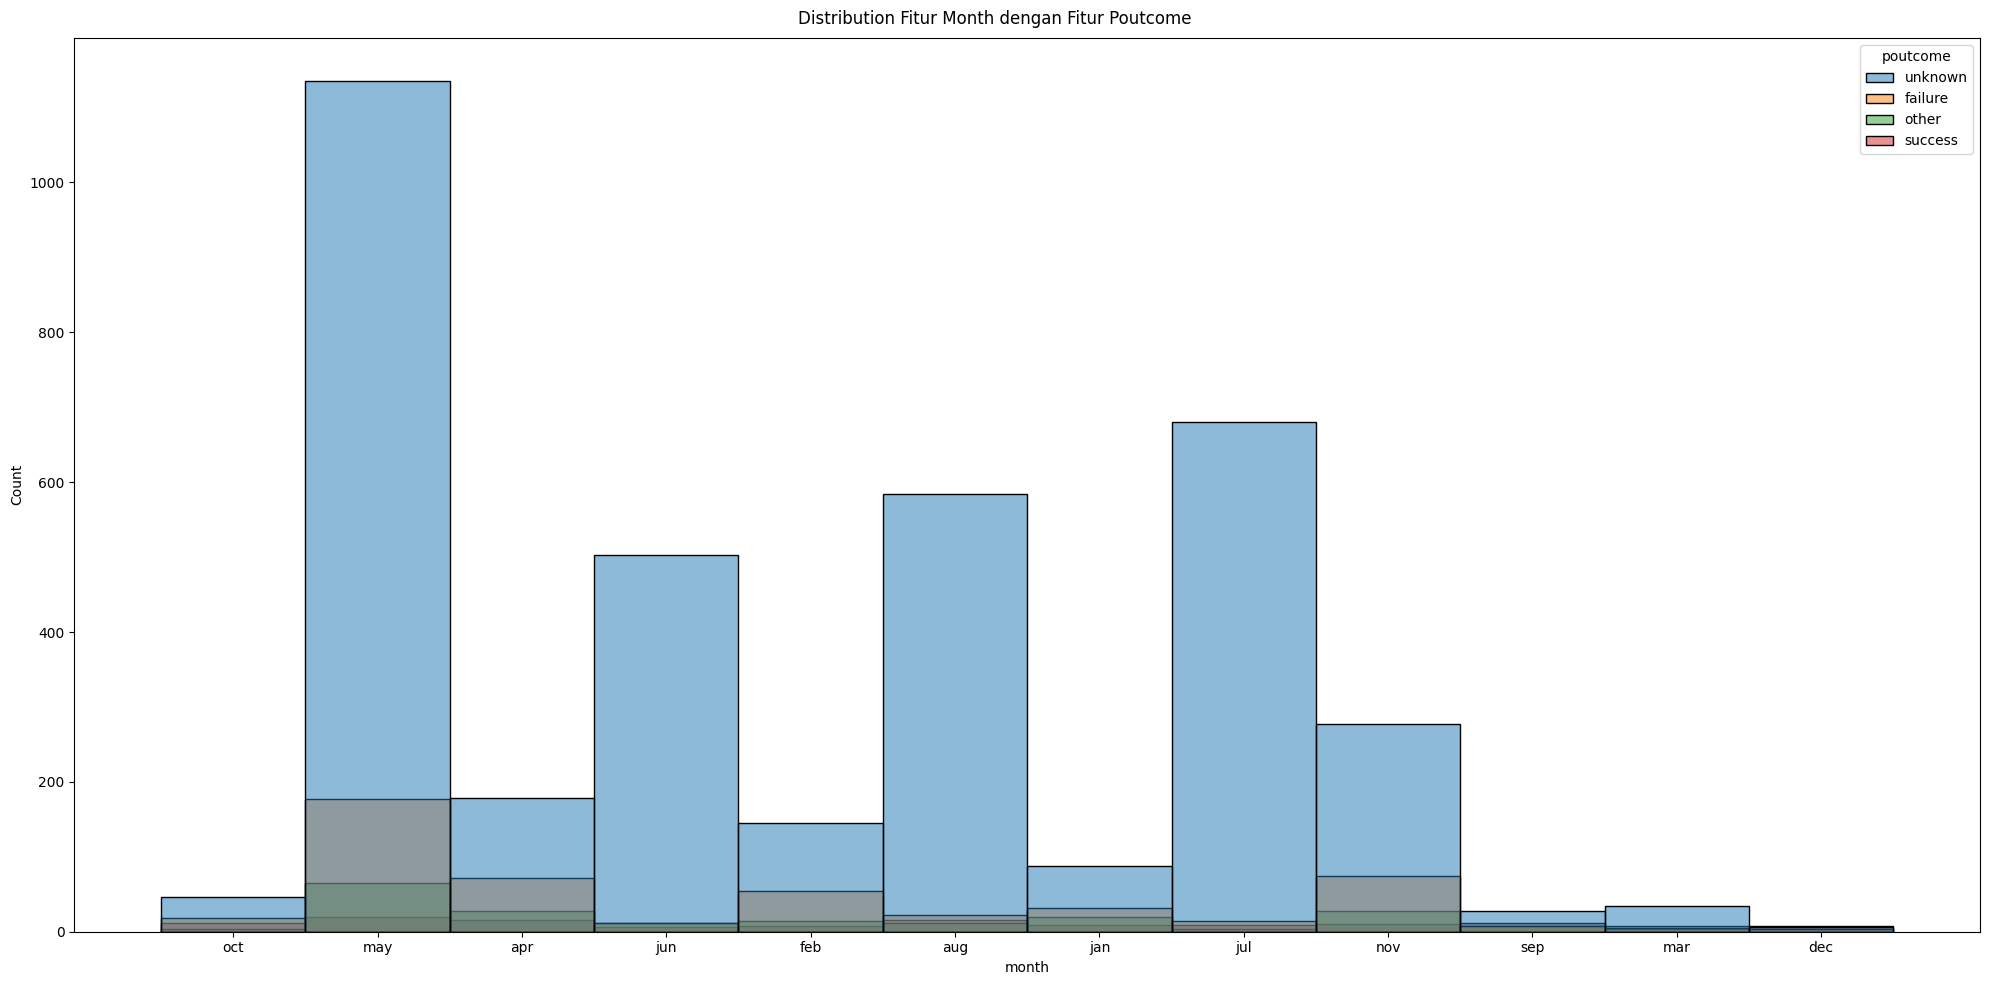

In [901]:
plt.figure(figsize=(20, 10))
sns.histplot(x=dataset["month"], hue=dataset['poutcome'])

plt.suptitle("Distribution Fitur Month dengan Fitur Poutcome")
plt.tight_layout()
plt.show()

#### *c. Fitur `Marital`*

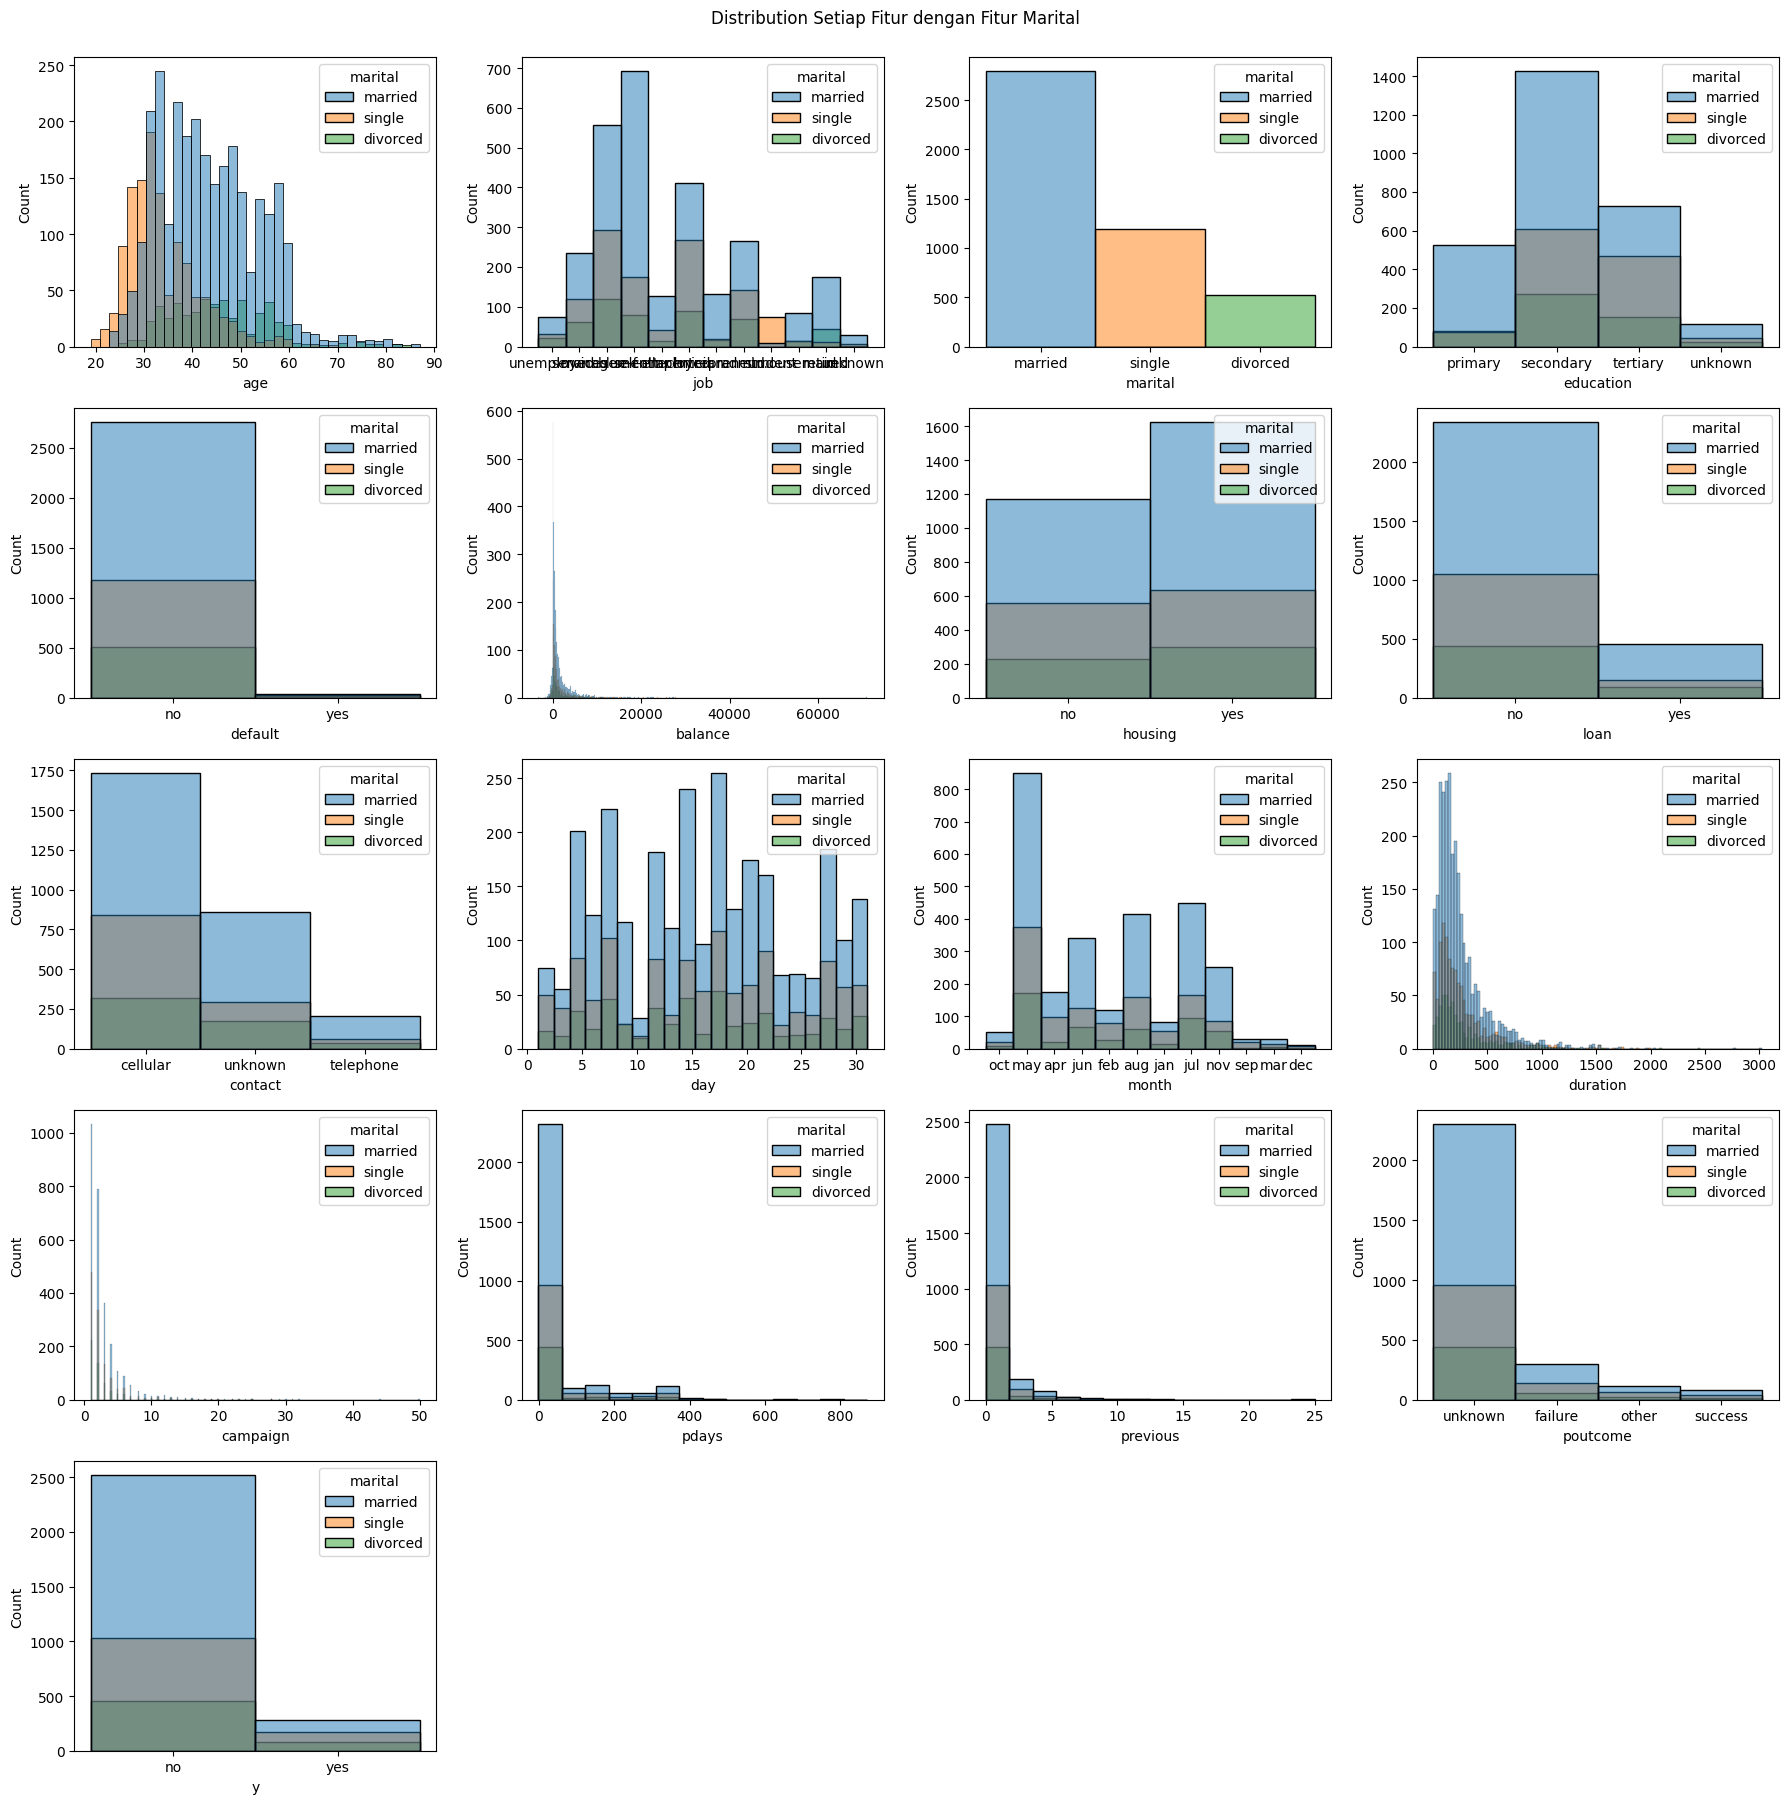

In [902]:
plt.figure(figsize=(18, 18))
for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset['marital'])

plt.suptitle("Distribution Setiap Fitur dengan Fitur Marital", y=1)
plt.tight_layout()
plt.show()

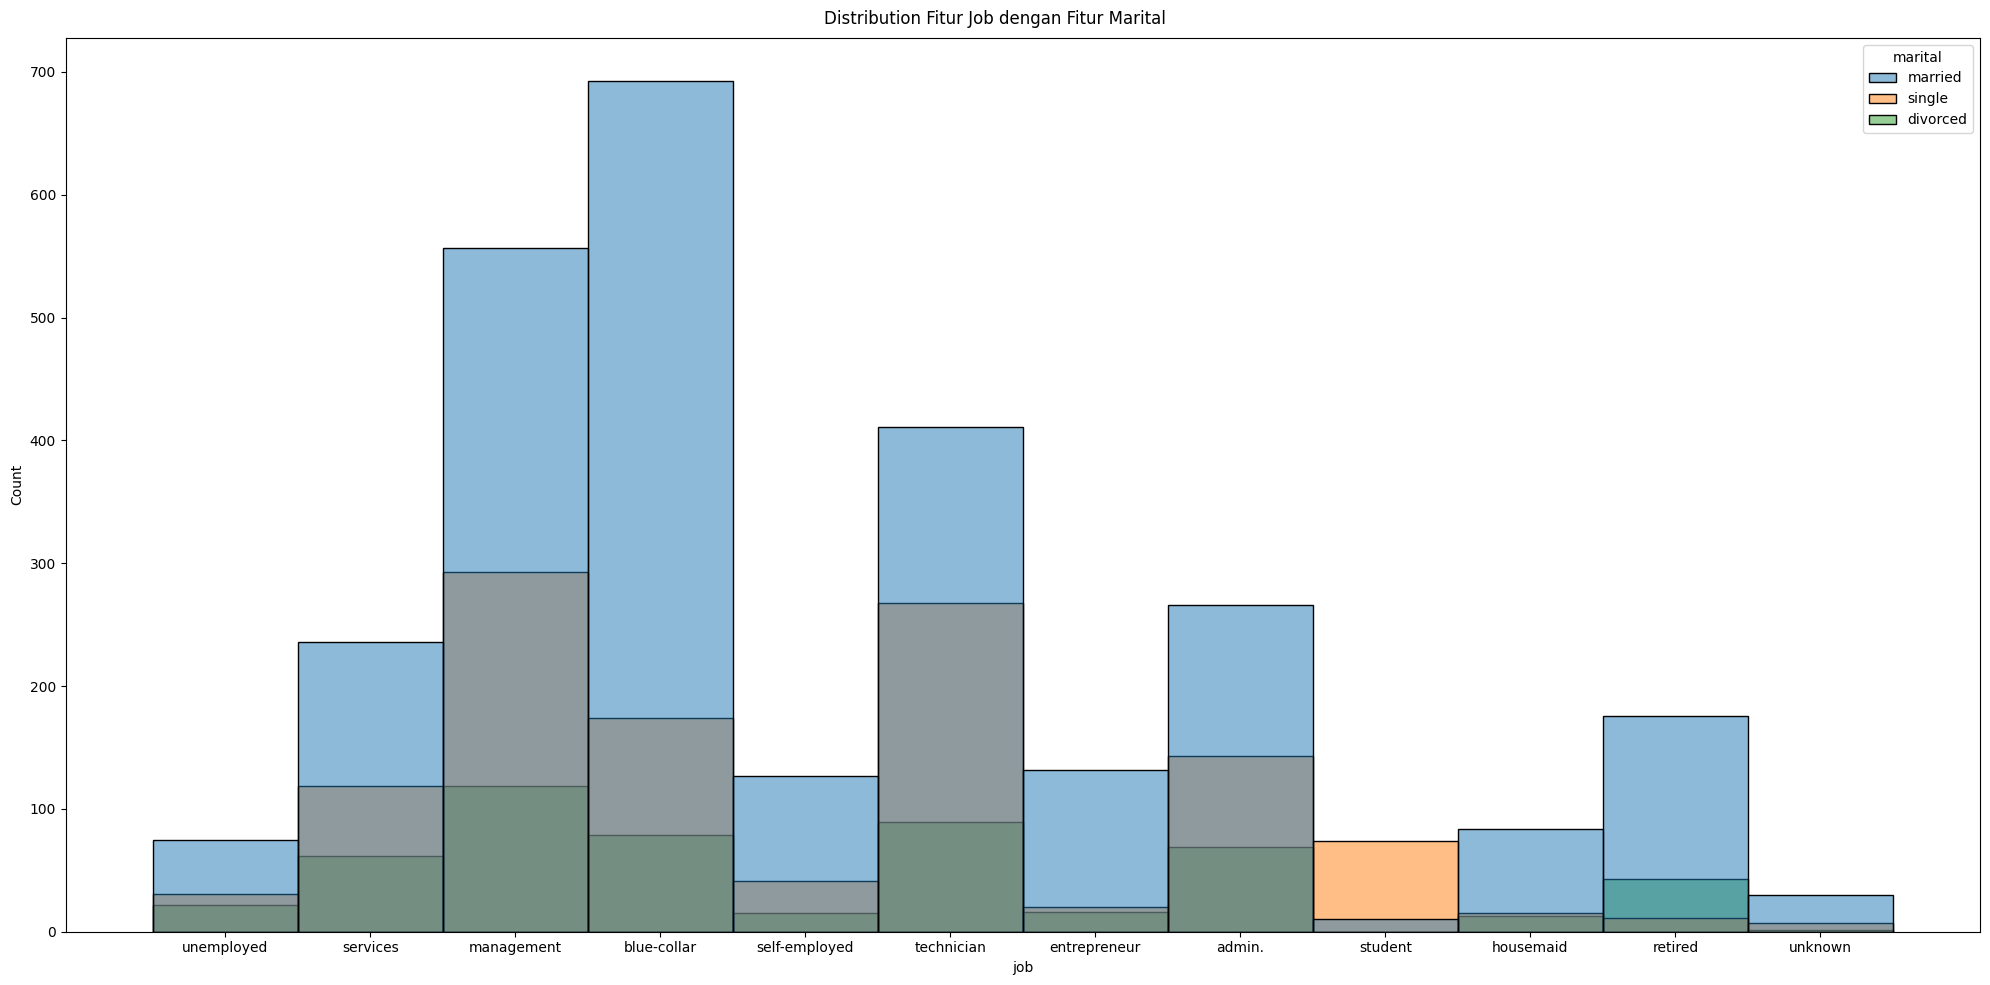

In [903]:
plt.figure(figsize=(20, 10))
sns.histplot(x=dataset["job"], hue=dataset['marital'])

plt.suptitle("Distribution Fitur Job dengan Fitur Marital")
plt.tight_layout()
plt.show()

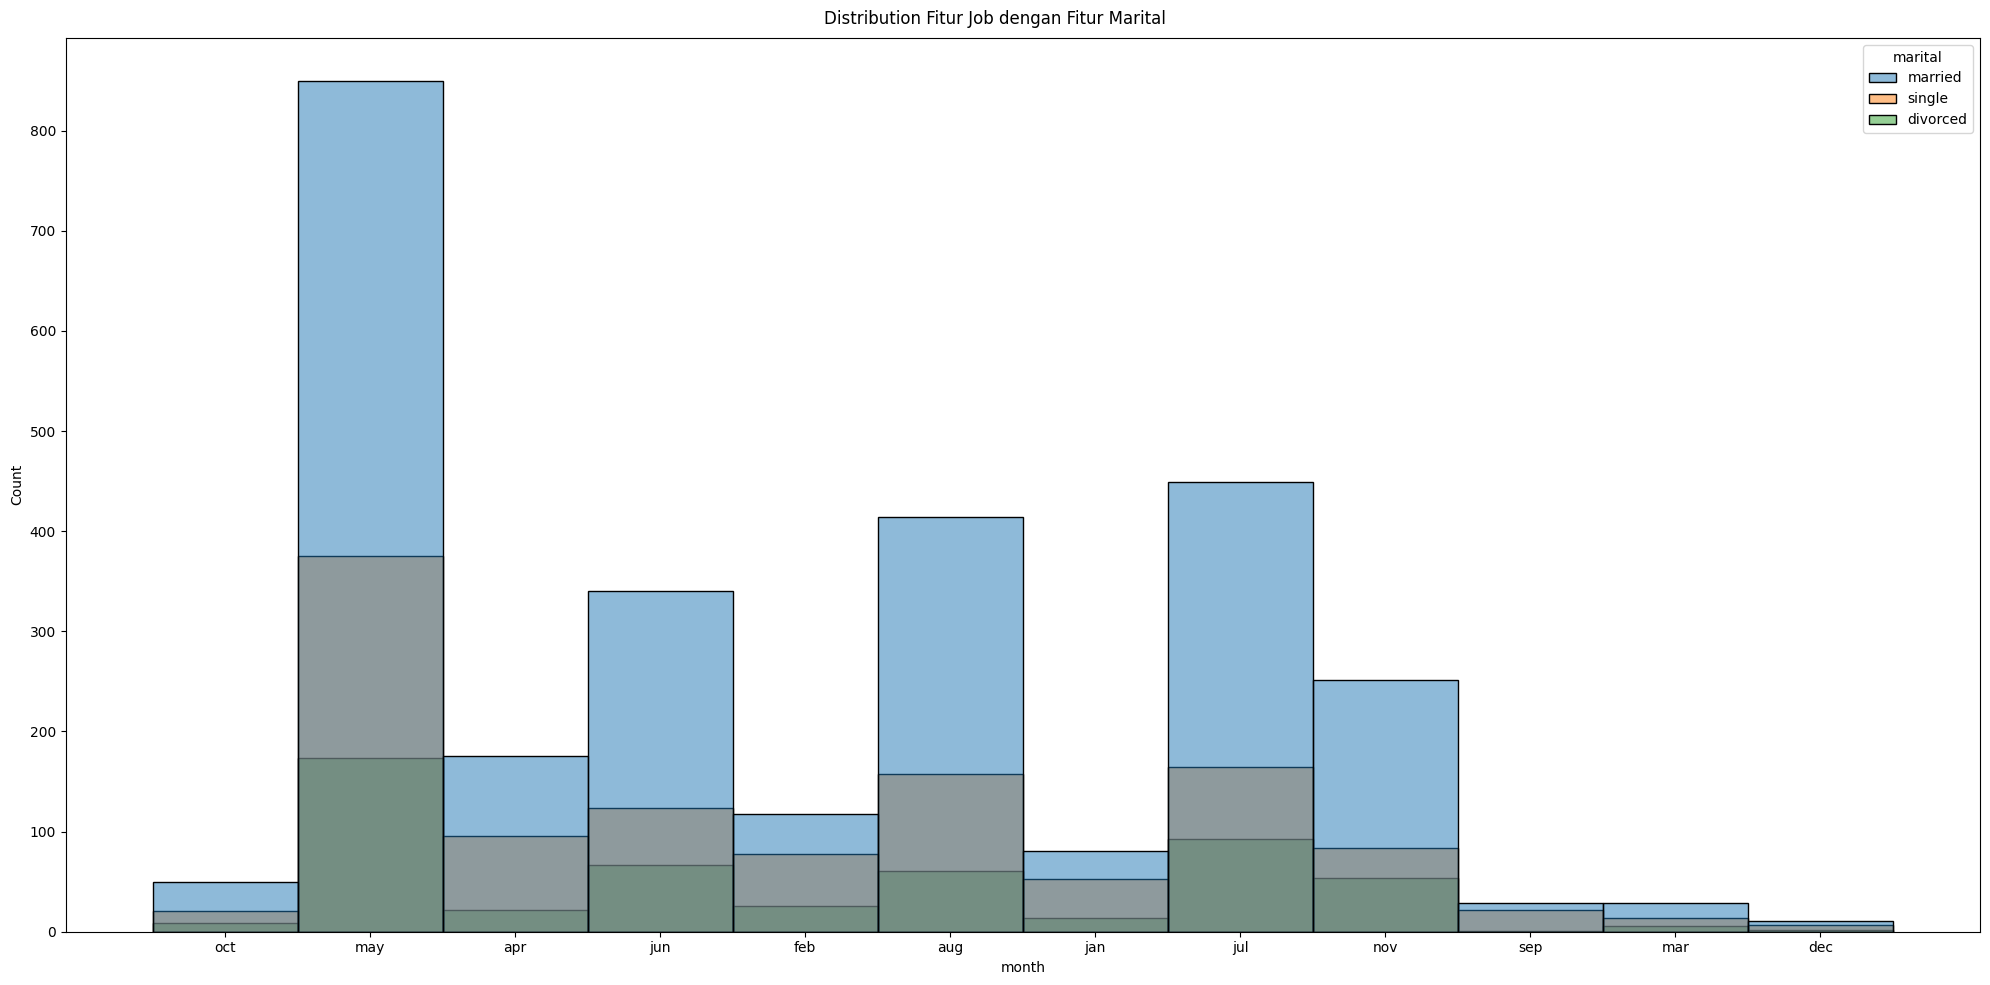

In [904]:
plt.figure(figsize=(20, 10))
sns.histplot(x=dataset["month"], hue=dataset['marital'])

plt.suptitle("Distribution Fitur Job dengan Fitur Marital")
plt.tight_layout()
plt.show()

## ***D. Evaluasi Model***

### 1. Fungsi Confusion Matrix

In [905]:
def confusion_matrix(y_true, y_pred, average):
    accuracy_array = []
    precision_array = []
    recall_array = []
    f1_array = []

    labels = np.unique(y_true)

    for label in labels:
        TP = np.sum((y_true == label) & (y_pred == label))
        FP = np.sum((y_true != label) & (y_pred == label))

        TN = np.sum((y_true != label) & (y_pred != label))
        FN = np.sum((y_true == label) & (y_pred != label))

        accuracy = (TP + TN) / (TP + TN + FP + FN) if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall)

        accuracy_array.append(accuracy)
        precision_array.append(precision)
        recall_array.append(recall)
        f1_array.append(f1_score)

    if average == 'macro':
        accuracy = np.mean(accuracy_array)
        precision = np.mean(precision_array)
        recall = np.mean(recall_array)
        f1_score = np.mean(f1_array)

    elif average == "micro":
        TP = np.sum(y_true == y_pred)
        FP = np.sum((y_true != y_pred) & (y_pred != y_true))

        TN = np.sum(y_true == y_pred)
        FN  = np.sum((y_true == y_pred) & (y_true != y_pred))

        accuracy = (TP + TN) / (TP + TN + FP + FN) if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall)
    
    return accuracy, precision, recall, f1_score

### 2. Evaluasi Model KNN

#### *a. Training Model*

In [906]:
acccuracy_train, precision_train, recall_train, f1_score_train = confusion_matrix(y_train, y_pred_train, average='micro')
print('-' * 30)
print(f"Akurasi train: {acccuracy_train:.2f}")
print('-' * 30)
print(f"Presisi train: {precision_train:.2f}")
print('-' * 30)
print(f"Recall train: {recall_train:.2f}")
print('-' * 30)
print(f"F1 Score train: {f1_score_train:.2f}")
print('-' * 30)

------------------------------
Akurasi train: 0.92
------------------------------
Presisi train: 0.85
------------------------------
Recall train: 1.00
------------------------------
F1 Score train: 0.92
------------------------------


#### *b. Testing Model*

In [907]:
acccuracy_test, precision_test, recall_test, f1_score_test = confusion_matrix(y_test, y_pred_test, average='micro')
print('-' * 30)
print(f"Akurasi test: {acccuracy_test:.2f}")
print('-' * 30)
print(f"Presisi test: {precision_test:.2f}")
print('-' * 30)
print(f"Recall test: {recall_test:.2f}")
print('-' * 30)
print(f"F1 Score test: {f1_score_test:.2f}")
print('-' * 30)

------------------------------
Akurasi test: 0.92
------------------------------
Presisi test: 0.85
------------------------------
Recall test: 1.00
------------------------------
F1 Score test: 0.92
------------------------------


### 3. Bias dan Variance Model

In [908]:
bias_knn = 1 - acccuracy_test
variance_knn = acccuracy_train - acccuracy_test

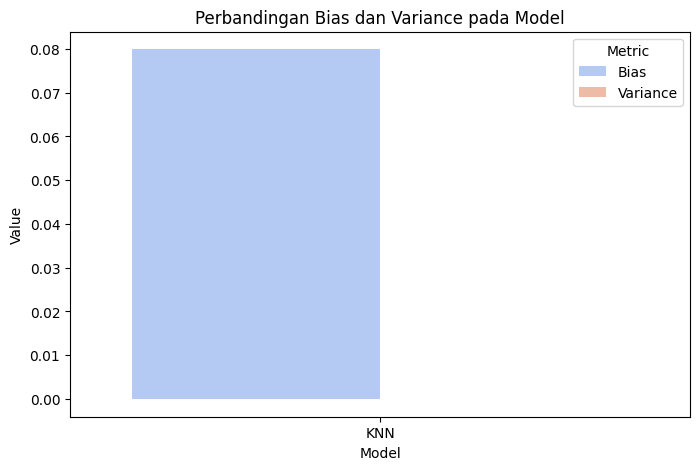

In [909]:
data = {
    "Model": ["KNN", "KNN"],
    "Metric": ["Bias", "Variance"],
    "Value": [bias_knn, variance_knn]
}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Model", y="Value", hue="Metric", palette="coolwarm")

plt.xlabel("Model")
plt.ylabel("Value")
plt.title("Perbandingan Bias dan Variance pada Model")
plt.legend(title="Metric")

plt.show()

### 4. Fungsi K-Fold Cross Validation

In [ ]:
def stratified_k_fold(X, y, model, k = 7):

    unique_classes, counts = np.unique(y, return_counts=True)
    class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
    folds = [[] for _ in range(k)]

    for cls, indices in class_indices.items():
        np.random.shuffle(indices)
        fold_sizes = np.array_split(indices, k)
        for i in range(k):
            folds[i].extend(fold_sizes[i])

    accuracies = []

    for i in range(k):
        train_idx = np.hstack([[j] for j in range(k) if j != i])
        test_idx = np.array(folds[i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy, _, _, _ = confusion_matrix(y_test, y_pred, average='micro')
        accuracies.append(accuracy)

        print(f"Fold: {i + 1} | Accuracy: {accuracy}")

    avg_acc = np.mean(accuracies)
    std_dev = np.std(accuracies)

    print(f"Average Accuracy Between Folds: {avg_acc}")
    print(f"Total Standard Deviation: {std_dev}")

    return avg_acc, std_dev

### 5. K-Fold Cross Validation Model KNN

In [ ]:
k_fold= stratified_k_fold(X_test, y_test, model)

Fold: 1 | Accuracy: 0.89 | F1 Score: 0.35
Fold: 2 | Accuracy: 0.87 | F1 Score: 0.32
Fold: 3 | Accuracy: 0.87 | F1 Score: 0.38
Fold: 4 | Accuracy: 0.85 | F1 Score: 0.29
Fold: 5 | Accuracy: 0.88 | F1 Score: 0.33
Fold: 6 | Accuracy: 0.91 | F1 Score: 0.57
Fold: 7 | Accuracy: 0.93 | F1 Score: 0.53
Fold: 8 | Accuracy: 0.85 | F1 Score: 0.00
Fold: 9 | Accuracy: 0.91 | F1 Score: 0.53

Average Accuracy Between Folds: 0.89
Total Standard Deviation: 0.03


# **V. Kesimpulan**

Ada beberapa kesimpulan yang bisa kami tarik dari analisa dan pengaplikasian model yang kami lakukan pada dataset ini, yaitu:
1. Model yang terbaik untuk dataset ini adalah KNN karena model berpeforma dengan optimal hampir perfect dengan hasil akurasi yang konsisten
2. Berapa lama calon nasabah melakukan panggilan ke bank, akan semakin mempengaruhi minat untuk menjadi nasabah, semakin lama semakin baik
3. Calon nasabah dengan HP/Cellular sebagai alat komunikasi memiliki minat untuk menjadi nasabah yang lebih tinggi ketimbang yang lain
4. Semakin sering bank melakukan contact ke calon nasabah sebelum kampanye pemasaran semakin berminat calon nasabah tersebut untuk menjadi nasabah setelah kampanye pemasaran dilakukan
5. Hasil dari kampanye pemasaran yang dilakukan akan sangat mempengaruhi minat nasabah

Dari analisa dan kesimpulan tersebut, maka saran yang dapat kami berikan kepada manager perusahaan bank:
1. Bank sebaiknya menggunakan strategi baru dalam berkomunikasi dengan calon nasabah agar tidak peduli device apa yang dimiliki calon nasabah semuanya berminat untuk join
2. Untuk sesi Customer Service sudah bagus karena mampu menaikkan minat calon nasabah, namun jika bisa bank bisa menemukan strategi untuk mempersingkat durasi contact kepada calon nasabah karena belum tentu semua calon nasabah ingin melakukan contact dengan durasi yang lama
3. Sebelum melakukan kampanye pemasaran bank sebaiknya mencari strategi untuk meningkatkan interaksi bank kepada calon nasabah agar result dari kampanye pemasaran yang dilakukan semakin bagus entah itu promosi atau sponsor ataupun simulasi
4. Jadi hal yang perlu dimaksimalkan adalah Interaksi bank dan bagaimana bank berinteraksi dengan calon nasabah